In [1]:
# Libs
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [2]:
df_ = pd.read_excel("/Users/matteovezzoli/Desktop/Book1.xlsx",sheet_name= "CD")


In [3]:
df = df_.copy()

In [4]:
df.dtypes

name                    object
team                    object
apps                     int64
mins                     int64
tackles                float64
ints                   float64
pos won                float64
blocks                 float64
clearances             float64
Ground Duels -total    float64
Ground Duels -won      float64
Ground Duels %         float64
Aerial Duels -total    float64
Aerial Duels -won      float64
Aerial Duels %         float64
dtype: object

In [5]:
df

,name,team,apps,mins,tackles,ints,pos won,blocks,clearances,Ground Duels -total,Ground Duels -won,Ground Duels %,Aerial Duels -total,Aerial Duels -won,Aerial Duels %
0,Isak Hien,Atalanta,22,1623,2.11,1.11,5.38,0.61,4.55,6.04,3.11,51.4,4.27,2.16,50.6
1,Jhon Lucumí,Bologna,19,1462,1.66,1.42,5.36,0.62,4.06,4.43,2.65,59.7,2.83,1.35,47.8
2,Giorgio Scalvini,Atalanta,14,1027,2.45,2.02,5.35,0.88,3.86,7.01,3.33,47.5,3.59,2.02,56.1
3,Oumar Solet,Udinese,26,2151,2.09,1.51,5.15,0.54,4.02,6.49,3.85,59.4,2.68,1.63,60.9
4,Lloyd Kelly,Juventus,24,2083,1.43,0.43,5.14,0.56,3.80,4.32,2.46,57.0,4.84,3.07,63.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,Sebastiano Luperto,Cremonese,23,2067,0.91,0.87,2.22,0.57,5.05,3.31,1.83,55.3,2.09,0.96,45.8
64,Matteo Bianchetti,Cremonese,20,1634,1.98,0.61,2.09,0.88,5.29,4.52,2.70,59.8,3.58,2.04,56.9
65,Martin Vitík,Bologna,14,957,1.97,0.66,2.07,0.56,5.92,4.51,2.35,52.1,5.45,2.82,51.7
66,Kialonda Gaspar,Lecce,22,1829,1.13,0.84,2.07,1.03,6.94,3.25,2.21,68.2,4.23,2.41,57.0


### Check Na & Distribution of variables

In [6]:
print(df.isna().sum())

name                   0
team                   0
apps                   0
mins                   0
tackles                0
ints                   0
pos won                0
blocks                 0
clearances             0
Ground Duels -total    0
Ground Duels -won      0
Ground Duels %         0
Aerial Duels -total    0
Aerial Duels -won      0
Aerial Duels %         0
dtype: int64


In [7]:
# Removing the redundant 'won' duels columns to avoid multicollinearity
columns_to_drop = ['Ground Duels -won', 'Aerial Duels -won']
df = df.drop(columns=columns_to_drop)

# Checking the updated dataframe
print("Current columns in the dataset are:")
print(df.columns.tolist())

Current columns in the dataset are:
['name', 'team', 'apps', 'mins', 'tackles', 'ints', 'pos won', 'blocks', 'clearances', 'Ground Duels -total', 'Ground Duels %', 'Aerial Duels -total', 'Aerial Duels %']


We dropped the *Won* columns to avoid multicollinearity. Since `Total * Percentage = Won`, keeping this redundant data would artificially inflate the weight of physical stats in the algorithm. 


## Handling Team Bias: Possession Adjustment (PAdj)

Comparing raw defensive volume metrics across different teams can be highly misleading. A defender playing for a team with low ball possession will naturally register more tackles, interceptions, and clearances simply because their team spends significantly more time defending. 

To create a fair, context-neutral comparison, we apply a standard football analytics technique: **Possession Adjustment (PAdj)**. 

By using the formula `Raw Metric * (50 / Opponent's Possession)`, we mathematically scale every defensive volume metric to a theoretical baseline where every team has exactly 50% ball possession. This removes the "opportunity bias" and highlights a player's true defensive proactivity. We apply this adjustment strictly to volume metrics (actions per 90), explicitly excluding efficiency metrics (such as Aerial Duels %) since percentages are already intrinsically normalized by their own attempts.

In [8]:
# Dictionary for team possession (Average % for the season)
team_possession_map = {
    'Como': 61.8, 'Inter': 60.4, 'Napoli': 58.4, 'Juventus': 57.2, 
    'Roma': 56.7, 'Atalanta': 55.1, 'Bologna': 55.1, 'Fiorentina': 52.7, 
    'Milan': 52.4, 'Lazio': 50.3, 'Genoa': 48.1, 'Cagliari': 46.0, 
    'Cremonese': 45.7, 'Parma': 45.2, 'Udinese': 45.1, 'Sassuolo': 44.8, 
    'Torino': 43.8, 'Lecce': 42.1, 'Hellas Verona': 40.3, 'Pisa': 39.6
}

# Mapping the possession percentage to each player
df['team_poss'] = df['team'].map(team_possession_map)

# Defining volume features to be adjusted
volume_features = [
    'tackles', 'ints', 'pos won', 'blocks', 
    'clearances', 'Ground Duels -total', 'Aerial Duels -total'
]

# Calculating PAdj metrics
for col in volume_features:
    # 100 - team_poss = Opponent's possession time
    df[f'{col}_padj'] = df[col] * (50 / (100 - df['team_poss']))

print("New PAdj columns added:")
print([col for col in df.columns if col.endswith('_padj')])
df.head()

New PAdj columns added:
['tackles_padj', 'ints_padj', 'pos won_padj', 'blocks_padj', 'clearances_padj', 'Ground Duels -total_padj', 'Aerial Duels -total_padj']


,name,team,apps,mins,tackles,ints,pos won,blocks,clearances,Ground Duels -total,...,Aerial Duels -total,Aerial Duels %,team_poss,tackles_padj,ints_padj,pos won_padj,blocks_padj,clearances_padj,Ground Duels -total_padj,Aerial Duels -total_padj
0,Isak Hien,Atalanta,22,1623,2.11,1.11,5.38,0.61,4.55,6.04,...,4.27,50.6,55.1,2.349666,1.236080,5.991091,0.679287,5.066815,6.726058,4.755011
1,Jhon Lucumí,Bologna,19,1462,1.66,1.42,5.36,0.62,4.06,4.43,...,2.83,47.8,55.1,1.848552,1.581292,5.968820,0.690423,4.521158,4.933185,3.151448
2,Giorgio Scalvini,Atalanta,14,1027,2.45,2.02,5.35,0.88,3.86,7.01,...,3.59,56.1,55.1,2.728285,2.249443,5.957684,0.979955,4.298441,7.806236,3.997773
3,Oumar Solet,Udinese,26,2151,2.09,1.51,5.15,0.54,4.02,6.49,...,2.68,60.9,45.1,1.903461,1.375228,4.690346,0.491803,3.661202,5.910747,2.440801
4,Lloyd Kelly,Juventus,24,2083,1.43,0.43,5.14,0.56,3.80,4.32,...,4.84,63.4,57.2,1.670561,0.502336,6.004673,0.654206,4.439252,5.046729,5.654206


## Feature Scaling: Z-Score Standardization

Before feeding our data into machine learning algorithms like PCA and K-Means, we must ensure all features are on the exact same mathematical scale. We apply Z-score standardization (`StandardScaler`) to give every metric a mean of 0 and a standard deviation of 1, preventing high-magnitude variables from unfairly dominating the model over smaller-scale percentages.

In [9]:
# We use PAdj versions for volumes and raw versions for efficiency (%)
features_to_standardize = [
    'tackles_padj',
    'ints_padj',
    'pos won_padj',
    'blocks_padj',
    'clearances_padj',
    'Ground Duels -total_padj',
    'Ground Duels %',
    'Aerial Duels -total_padj',
    'Aerial Duels %'
]

X = df[features_to_standardize]

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

df_scaled_tmp = pd.DataFrame(X_scaled_array, columns=features_to_standardize, index=df.index)

for col in features_to_standardize:
    df[col + '_z'] = df_scaled_tmp[col]

z_columns = [col + '_z' for col in features_to_standardize]

print("Standardization (Z-score) completed.")
print("Preview of the normalized and scaled dataset:")
print(df[['name'] + z_columns].head())

Standardization (Z-score) completed.
Preview of the normalized and scaled dataset:
                name  tackles_padj_z  ints_padj_z  pos won_padj_z  \
0          Isak Hien        1.501855     0.271518        1.996774   
1        Jhon Lucumí        0.574944     1.118353        1.977719   
2   Giorgio Scalvini        2.202187     2.757388        1.968191   
3        Oumar Solet        0.676508     0.612859        0.883888   
4        Lloyd Kelly        0.245712    -1.528420        2.008394   

   blocks_padj_z  clearances_padj_z  Ground Duels -total_padj_z  \
0       0.047004           0.213999                    1.803477   
1       0.089132          -0.217774                    0.406667   
2       1.184462          -0.394008                    2.645033   
3      -0.662268          -0.898249                    1.168276   
4      -0.047883          -0.282585                    0.495128   

   Ground Duels %_z  Aerial Duels -total_padj_z  Aerial Duels %_z  
0         -0.521827            

To ensure our standardization worked correctly, we can plot the distributions of our features before and after scaling. As we can see below, the shape of the data remains exactly the same, but the x-axis has been shifted to a Z-score scale (mean = 0, standard deviation = 1).

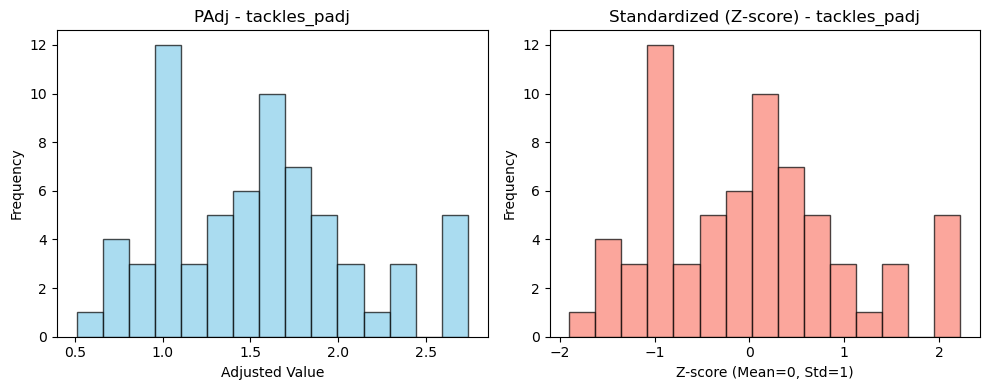

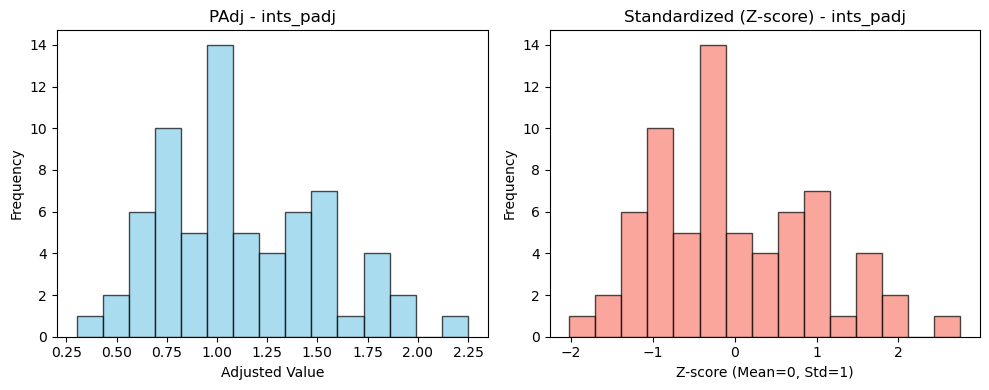

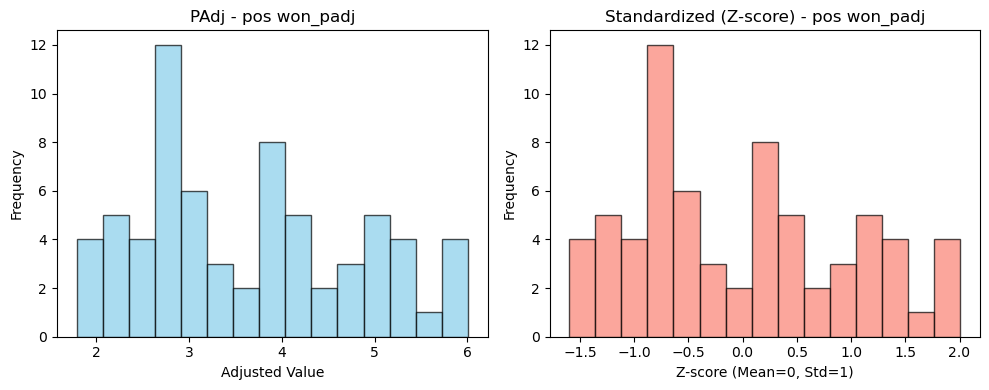

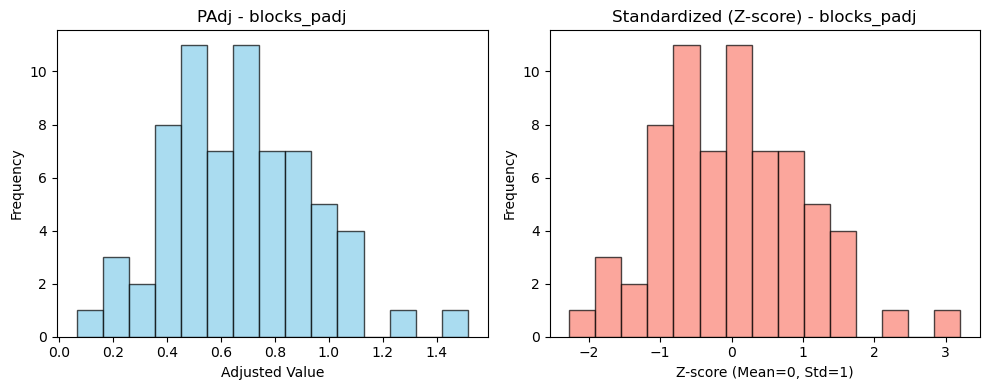

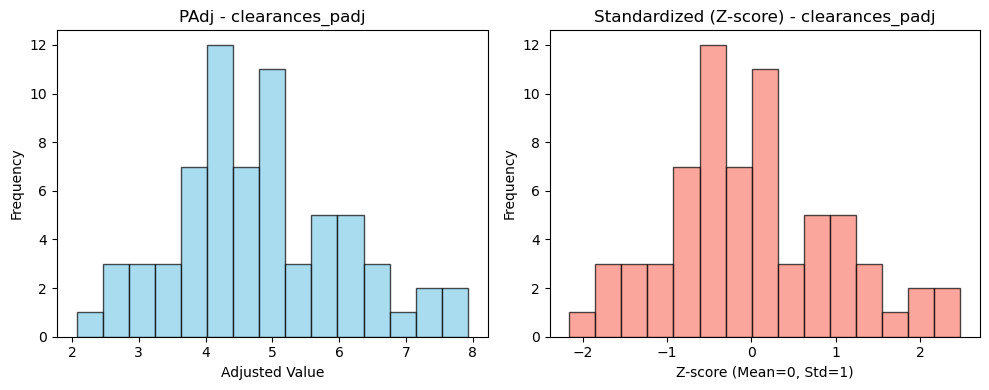

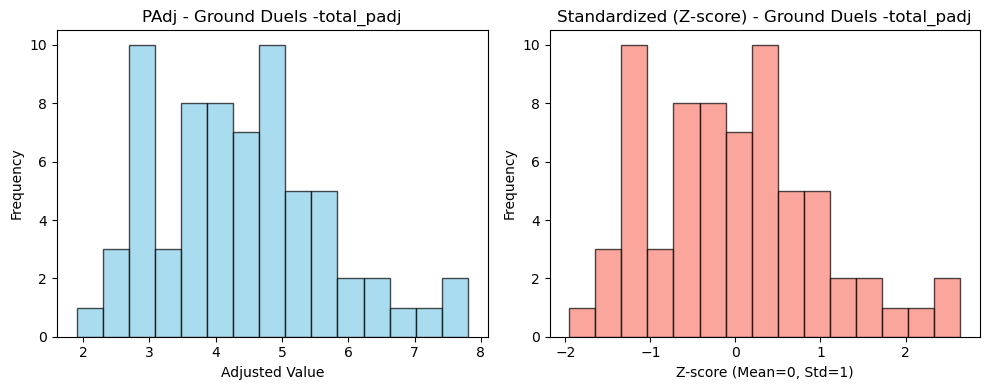

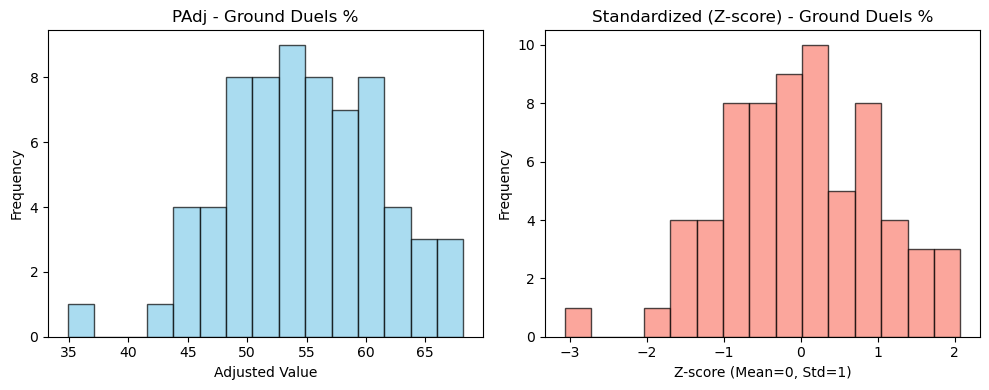

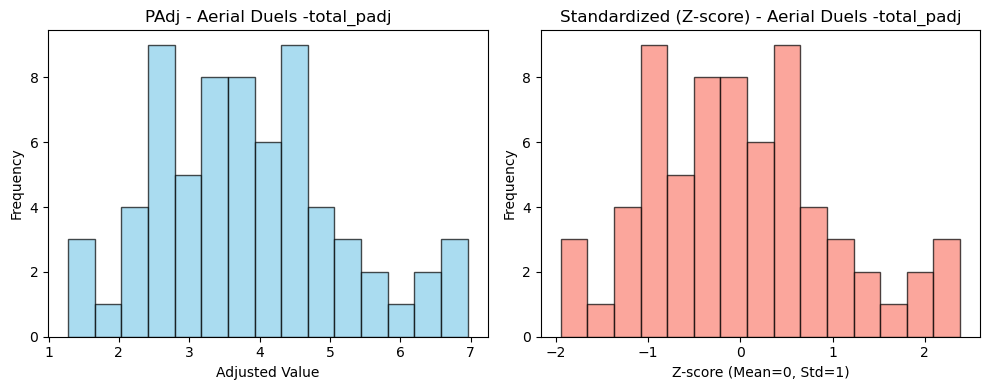

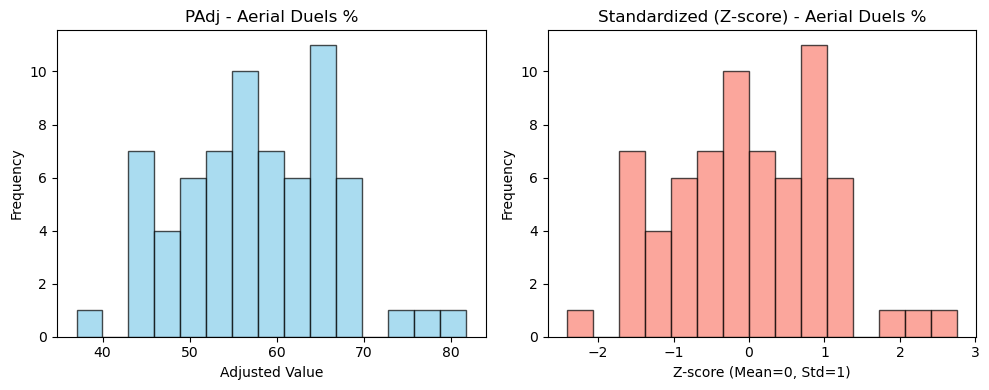

In [10]:
# We iterate through the list of features used in the standardization step
for col in features_to_standardize:
    plt.figure(figsize=(10, 4))
    
    # 1. Possession-Adjusted Distribution (Pre-Standardization)
    plt.subplot(1, 2, 1)
    plt.hist(df[col], bins=15, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f"PAdj - {col}")
    plt.xlabel("Adjusted Value")
    plt.ylabel("Frequency")
    
    # 2. Standardized Distribution (Z-score)
    # We access the '_z' columns we created in the previous step
    z_col = col + '_z'
    plt.subplot(1, 2, 2)
    plt.hist(df[z_col], bins=15, color='salmon', edgecolor='black', alpha=0.7)
    plt.title(f"Standardized (Z-score) - {col}")
    plt.xlabel("Z-score (Mean=0, Std=1)")
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

### Boxplot Analysis

In [11]:
def outlier_thresholds(dataframe, col_name):
    quartile1 = dataframe[col_name].quantile(0.25)
    quartile3 = dataframe[col_name].quantile(0.75)
    interquartile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquartile_range
    low_limit = quartile1 - 1.5 * interquartile_range
    return low_limit.round(1), up_limit.round(1)

def boxplot_all(dataframe, col_names, figsize=(14,6), rotate=45):    
    data = [dataframe[c].dropna().values for c in col_names]

    plt.figure(figsize=figsize)
    plt.boxplot(
        data,
        labels=col_names,
        showfliers=True,
        whis=1.5
    )
    plt.xticks(rotation=rotate, ha="right")
    plt.title("Boxplot (All selected columns)")
    plt.tight_layout()
    plt.show()

def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

def show_outliers(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    outliers = dataframe[(dataframe[col_name] < low_limit) | (dataframe[col_name] > up_limit)]
    if not outliers.empty:
        print(f"Outliers in {col_name} (thresholds: {low_limit}, {up_limit}):")
        print(outliers[['name', col_name]])
    else:
        print(f"No outliers found in {col_name}")


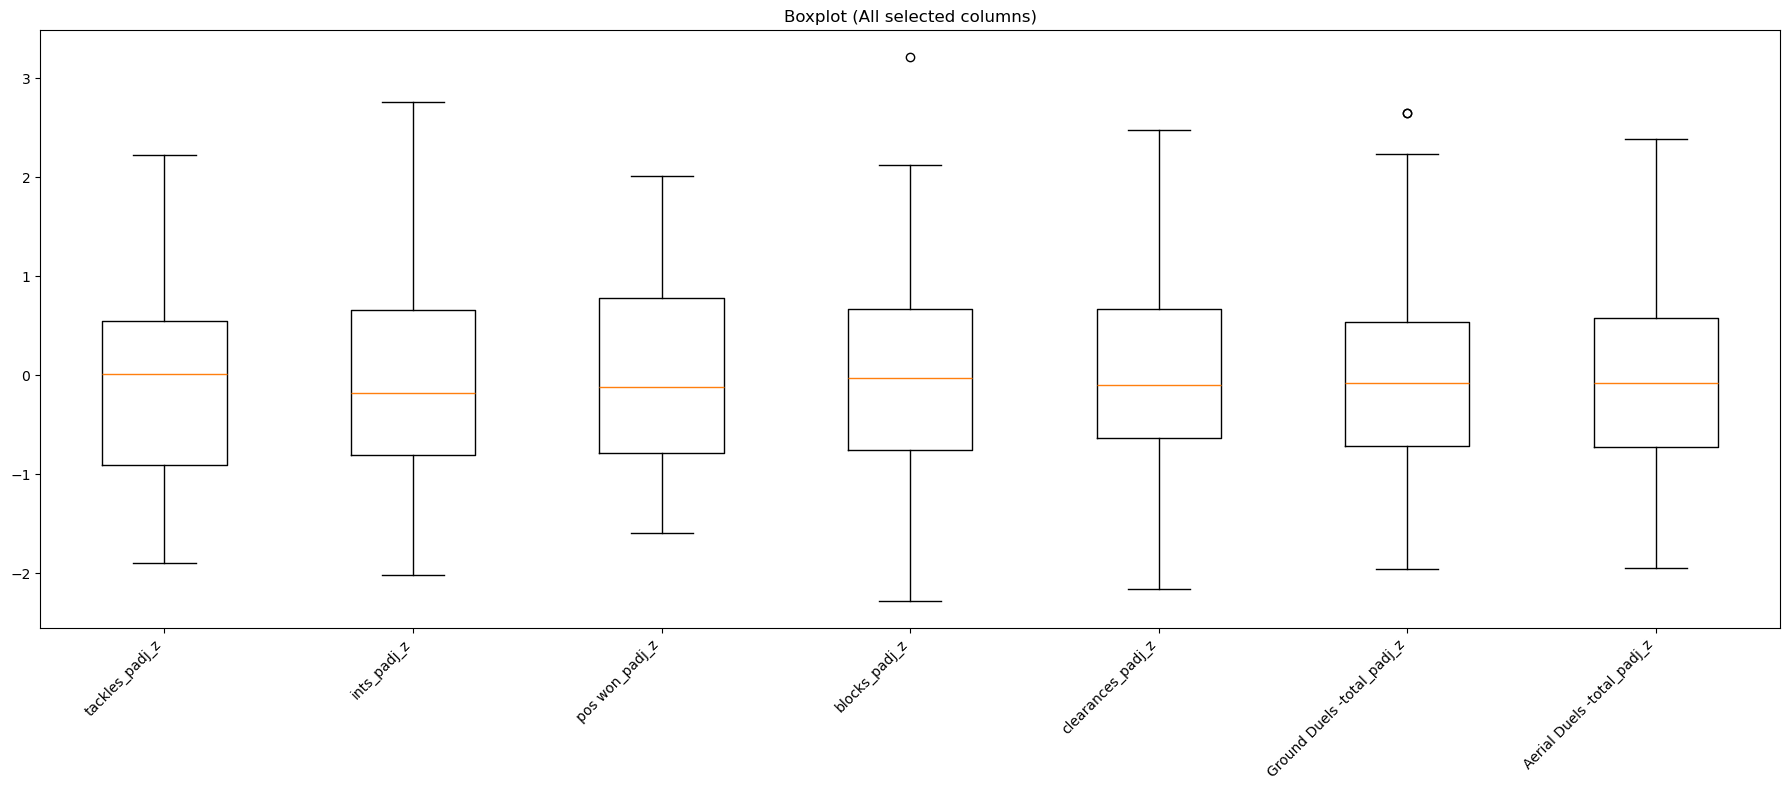

No outliers found in tackles_padj_z
No outliers found in ints_padj_z
No outliers found in pos won_padj_z
Outliers in blocks_padj_z (thresholds: -2.9, 2.8):
                 name  blocks_padj_z
37   Francesco Acerbi       3.209164
No outliers found in clearances_padj_z
Outliers in Ground Duels -total_padj_z (thresholds: -2.6, 2.4):
                 name  Ground Duels -total_padj_z
2    Giorgio Scalvini                    2.645033
59      Honest Ahanor                    2.645033
No outliers found in Aerial Duels -total_padj_z


In [12]:
cols_z_padj = [col for col in df.columns if 'padj' in col and col.endswith('_z')]

boxplot_all(df, cols_z_padj, figsize=(18,8), rotate=45)

for col in cols_z_padj:
    show_outliers(df, col)
    print("==============")

### Outlier Detection (Post-PAdj & Standardization)

After applying **Possession-Adjustment (PAdj)** and standardizing the features, the outlier landscape has significantly shifted. By neutralizing the "team possession bias," the IQR method (1.5 * IQR) now highlights players whose defensive activity is statistically exceptional relative to their actual time spent defending.

The analysis identified three primary statistical anomalies:

* **Francesco Acerbi (Blocks):** Emerges as a significant outlier in `blocks_padj_z` (+3.21). This indicates an elite ability to obstruct shots and passes, even within a high-possession system like Inter's, where defensive opportunities are limited.
* **Giorgio Scalvini & Honest Ahanor (Ground Duels):** Both Atalanta defenders appear as outliers in `Ground Duels -total_padj_z` (+2.65). This suggests a specific tactical instruction or individual profile characterized by extreme aggression and high volume of ground engagements per defensive minute.

Interestingly, metrics like **Tackles** and **Interceptions** no longer show outliers after PAdj, suggesting a more uniform distribution of these actions across the dataset once team context is leveled.

### Correlation Matrix Heatmap

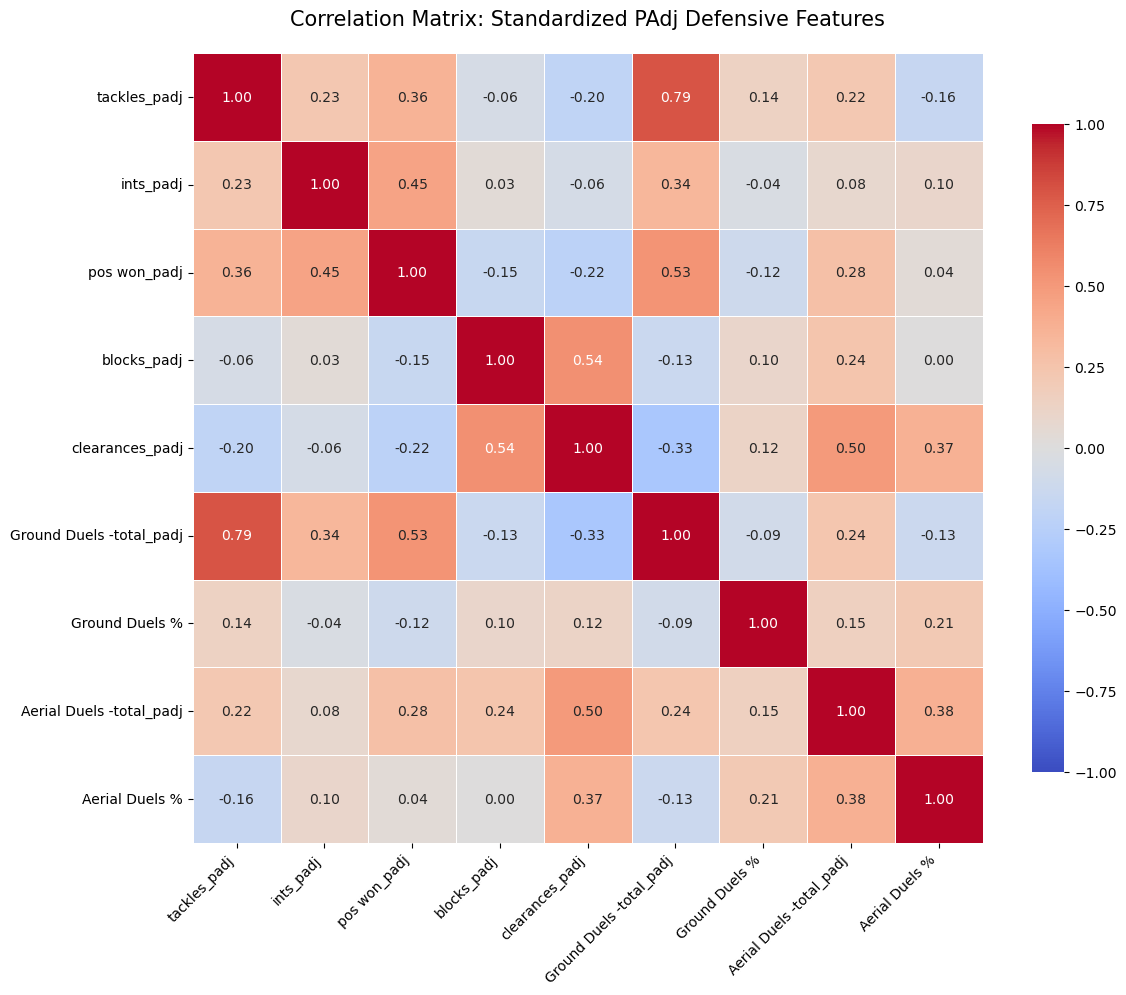

In [13]:
# We use the df_scaled DataFrame which contains our 9 final features 
# (6 PAdj volumes + 3 original percentages) already standardized.
corr_matrix = df_scaled_tmp.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix, 
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    vmin=-1, vmax=1,     
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix: Standardized PAdj Defensive Features", fontsize=15, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

In [14]:
corr_pairs = corr_matrix.unstack()

sorted_pairs = corr_pairs.abs().sort_values(ascending=False)

top_5_corr = []
seen_pairs = set()

for (f1, f2), val in sorted_pairs.items():
    if f1 != f2 and (f1, f2) not in seen_pairs and (f2, f1) not in seen_pairs:
        top_5_corr.append(((f1, f2), corr_matrix.loc[f1, f2]))
        seen_pairs.add((f1, f2))
    if len(top_5_corr) == 5:
        break

print("Top 5 Feature Correlations:")
print("-" * 30)
for (pair, val) in top_5_corr:
    print(f"{pair[0]} & {pair[1]}: {val:.3f}")

Top 5 Feature Correlations:
------------------------------
Ground Duels -total_padj & tackles_padj: 0.790
clearances_padj & blocks_padj: 0.539
pos won_padj & Ground Duels -total_padj: 0.528
Aerial Duels -total_padj & clearances_padj: 0.497
ints_padj & pos won_padj: 0.449


After neutralizing the possession bias, the correlation matrix reveals the pure statistical relationships between defensive actions:

* **0.79 – Ground Duels & Tackles:** Strongest link. Total ground activity and tackling volume are mathematically tied, representing the same physical engagement.
* **0.54 – Clearances & Blocks:** Moderate connection between "emergency" actions. Players clearing the ball frequently also tend to block more shots.
* **0.53 – Pos Won & Ground Duels:** Clear link between the total volume of ground engagements and the ability to regain possession.
* **0.50 – Aerial Duels & Clearances:** Co-occurrence of aerial challenges and clearances, often reflecting the defense of crosses and long balls.
* **0.45 – Interceptions & Pos Won:** Correlation between reading passing lanes and clean ball recoveries.

### The Ground Engagers (Ground Duels vs. Tackles)

This scatterplot maps the total volume of ground engagements against the number of tackles per 90 minutes. Both metrics are Possession-Adjusted (PAdj) to ensure a fair comparison across different team styles. This chart perfectly visualizes the strong positive correlation (0.79) we discovered in the heatmap. The clear diagonal trend confirms that tackling is rarely an isolated action; it is a direct byproduct of engaging in ground duels. Notice how the top-left quadrant is virtually empty. Statistically, it's almost impossible in Serie A to register a high volume of tackles without also recording a high number of overall ground duels. It is important to note that this chart measures defensive volume and stylistic tendencies, not efficiency. It maps out 'how often' a player engages, rather than their win percentage in those specific situations.

Players like **Giorgio Scalvini**, **Honest Ahanor**, and **Carlos Augusto** dominate the top-right corner. Their data profile screams an ultra-aggressive, high-intensity defensive style. On the opposite end, players like **Matteo Gabbia**, **Alessio Romagnoli**, and **Christian Kabasele** sit in the bottom-left. This doesn't mean they are poor defenders; it simply highlights a more passive, positional style where they prefer to hold the line rather than going to ground.


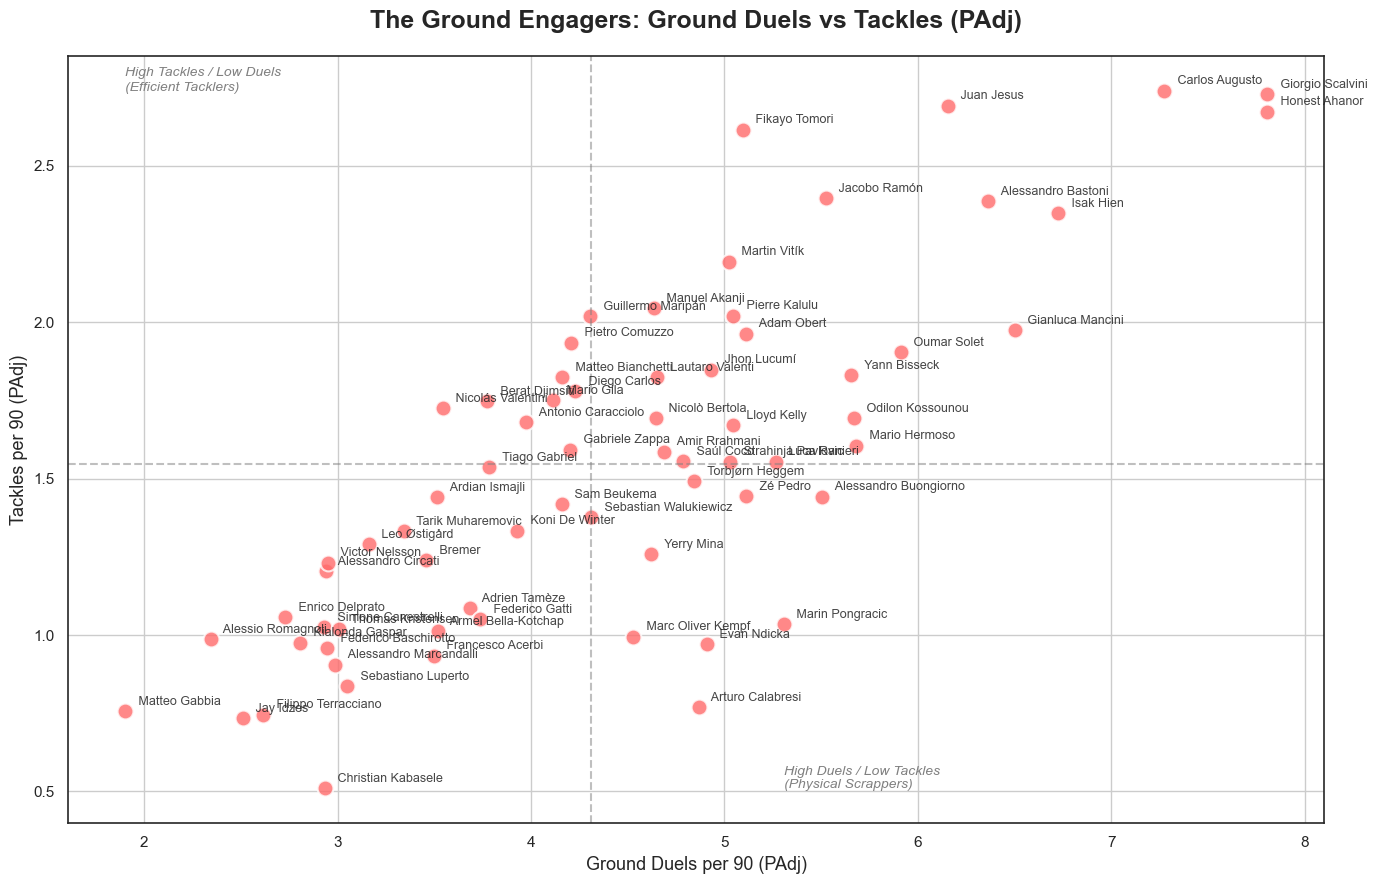

In [15]:
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "0.15", "axes.linewidth": 1.2})

plt.figure(figsize=(14, 9))

plt.scatter(df['Ground Duels -total_padj'], df['tackles_padj'], 
            color='#FF6B6B', s=130, alpha=0.8, edgecolor='white', linewidth=1.5)

for i, row in df.iterrows():
    plt.text(row['Ground Duels -total_padj'] + 0.05, row['tackles_padj'] + 0.02, 
             row['name'], fontsize=9, alpha=0.85)

plt.axvline(x=df['Ground Duels -total_padj'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=df['tackles_padj'].median(), color='gray', linestyle='--', alpha=0.5)

plt.title('The Ground Engagers: Ground Duels vs Tackles (PAdj)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Ground Duels per 90 (PAdj)', fontsize=13)
plt.ylabel('Tackles per 90 (PAdj)', fontsize=13)

plt.text(df['Ground Duels -total_padj'].min(), df['tackles_padj'].max(), 'High Tackles / Low Duels\n(Efficient Tacklers)', fontsize=10, color='gray', style='italic')
plt.text(df['Ground Duels -total_padj'].max() - 2.5, df['tackles_padj'].min(), 'High Duels / Low Tackles\n(Physical Scrappers)', fontsize=10, color='gray', style='italic')

plt.tight_layout()
plt.show()

### Defensive Proactivity (Tackles vs. Interceptions)

This scatterplot compare pure aggressiveness (Tackles) against the tactical reading of the game (Interceptions). Both metrics are Possession-Adjusted (PAdj), splitting defenders into four distinct quadrants based on their preferred ball-recovery style. The top-left isolates the "readers" who anticipate passing lanes, while the bottom-right isolates who rely heavily on tackling. Once again, it is important to note that this chart measures defensive volume and stylistic tendencies, not efficiency. It maps out 'how' a player prefers to win the ball back, rather than their absolute success rate in doing so.

Players like **Francesco Acerbi** and **Armel Bella-Kotchap** sit high on the y-axis but low on the x-axis, highlighting an anticipatory style based on positioning and intercepting passes rather than going to ground. On the opposite end of the spectrum, players like **Fikayo Tomori** and **Carlos Augusto** populate the bottom-right corner, acting as aggressive enforcers who register a massive volume of tackles but fewer interceptions. Finally, complete statistical dominators like **Giorgio Scalvini** and **Juan Jesus** isolate themselves in the top-right corner, executing both proactive actions at an exceptionally high volume compared to the rest of the league.

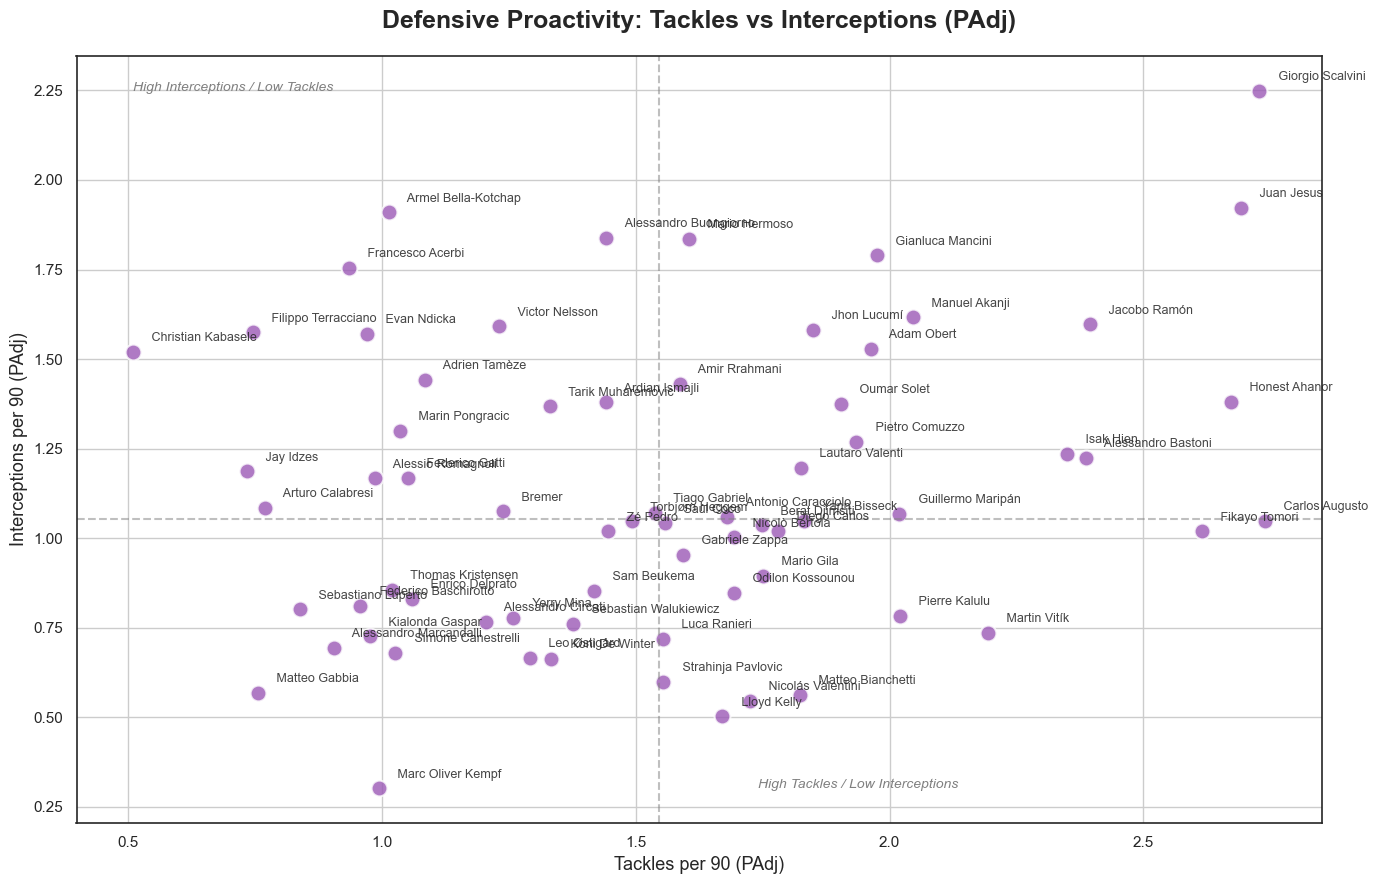

In [16]:
plt.figure(figsize=(14, 9))

plt.scatter(df['tackles_padj'], df['ints_padj'], 
            color='#9B59B6', s=130, alpha=0.8, edgecolor='white', linewidth=1.5)

for i, row in df.iterrows():
    plt.text(row['tackles_padj'] + 0.03, row['ints_padj'] + 0.03, 
             row['name'], fontsize=9, alpha=0.85)

plt.axvline(x=df['tackles_padj'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=df['ints_padj'].median(), color='gray', linestyle='--', alpha=0.5)

plt.title('Defensive Proactivity: Tackles vs Interceptions (PAdj)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Tackles per 90 (PAdj)', fontsize=13)
plt.ylabel('Interceptions per 90 (PAdj)', fontsize=13)

plt.text(df['tackles_padj'].min(), df['ints_padj'].max(), 'High Interceptions / Low Tackles', fontsize=10, color='gray', style='italic')
plt.text(df['tackles_padj'].max() - 1, df['ints_padj'].min(), 'High Tackles / Low Interceptions', fontsize=10, color='gray', style='italic')

plt.tight_layout()
plt.show()

### The Box Protectors (Clearances vs. Blocks)

This scatterplot maps the radar of deep positional defending, measuring actions typically performed inside a team's own penalty area: clearing the ball away versus throwing a body in front of shots. Adjusted for possession (PAdj), it separates box defenders into distinct tactical categories. The horizontal axis highlights the "sweepers" who actively clear danger, while the vertical axis highlights the "shot-blockers" who frequently intercept shots. Once again, it is important to note that this chart measures defensive volume and stylistic tendencies, not efficiency. It maps out 'how often' a player engages in last-ditch defending, rather than their absolute success rate.

Looking at the extremes, players like **Diego Carlos** and **Marc Oliver Kempf** stretch far to the right, identifying themselves as pure sweepers who excel at consistently clearing the ball. On the vertical axis, defenders like **Saúl Coco** and **Sam Beukema** sit high as dedicated shot-blockers who prioritize closing down shooting angles. Meanwhile, **Francesco Acerbi** stands out as a total statistical anomaly in the top-right corner, dominating both metrics at an unprecedented volume. Conversely, players in the bottom-left like **Gabriele Zappa** and **Pierre Kalulu** register low numbers in both, simply because they play in tactical systems or specific roles (such as wide center-backs in a high line) that naturally keep them away from desperate box-defending situations.

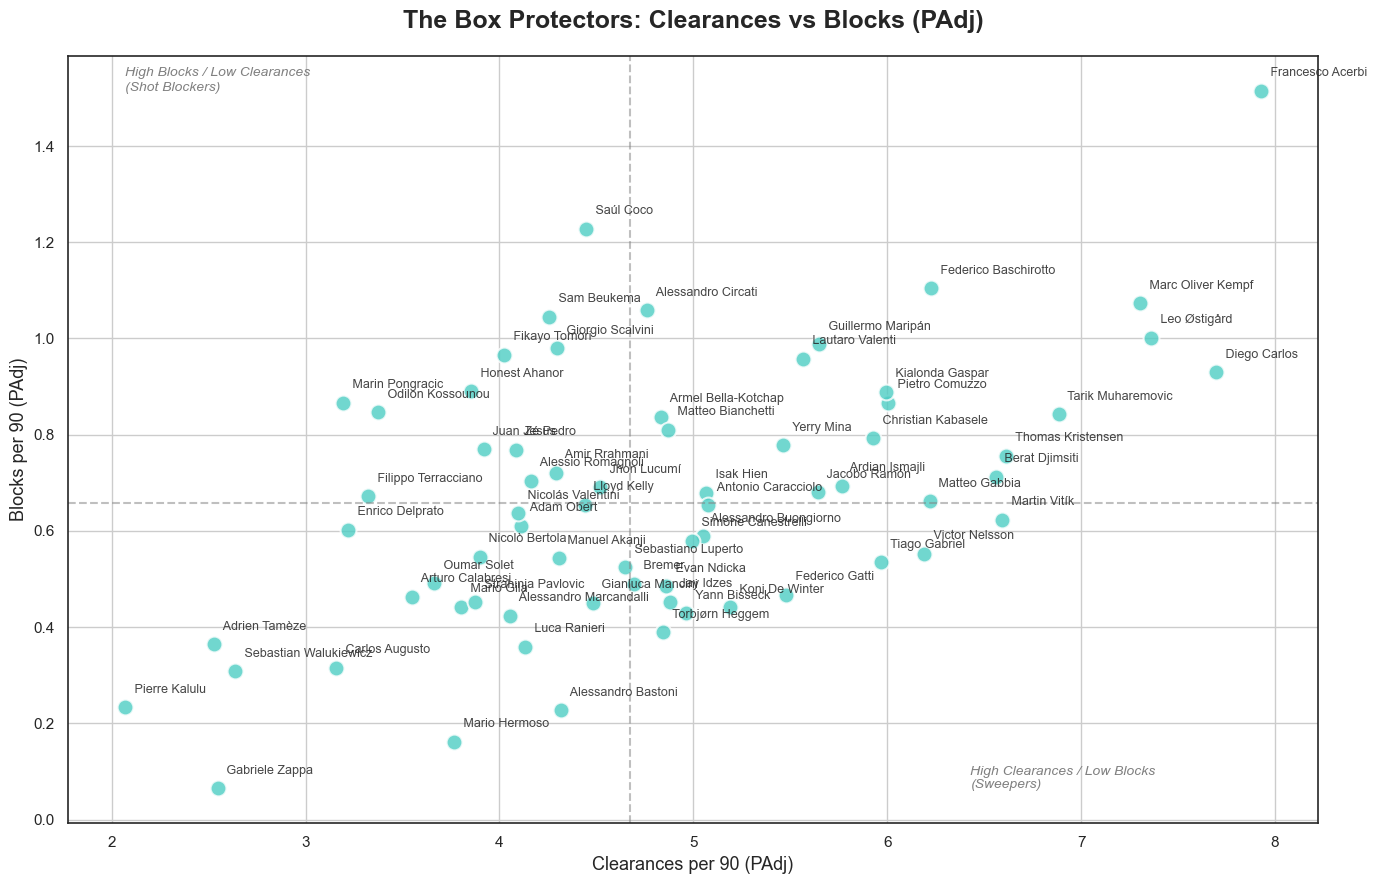

In [17]:
plt.figure(figsize=(14, 9))

plt.scatter(df['clearances_padj'], df['blocks_padj'], 
            color='#4ECDC4', s=130, alpha=0.8, edgecolor='white', linewidth=1.5)

for i, row in df.iterrows():
    plt.text(row['clearances_padj'] + 0.03, row['blocks_padj'] + 0.03, 
             row['name'], fontsize=9, alpha=0.85)

plt.axvline(x=df['clearances_padj'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=df['blocks_padj'].median(), color='gray', linestyle='--', alpha=0.5)

plt.title('The Box Protectors: Clearances vs Blocks (PAdj)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Clearances per 90 (PAdj)', fontsize=13)
plt.ylabel('Blocks per 90 (PAdj)', fontsize=13)

plt.text(df['clearances_padj'].min(), df['blocks_padj'].max(), 'High Blocks / Low Clearances\n(Shot Blockers)', fontsize=10, color='gray', style='italic')
plt.text(df['clearances_padj'].max() - 1.5, df['blocks_padj'].min(), 'High Clearances / Low Blocks\n(Sweepers)', fontsize=10, color='gray', style='italic')

plt.tight_layout()
plt.show()

### Combat Domains (Ground vs. Aerial Activity)

This scatterplot answers a fundamental scouting question: where does this defender primarily fight? By crossing the volume of aerial duels with ground duels, both possession-adjusted (PAdj), we can map out a player's primary combat domain. The quadrants clearly separate the pure aerial specialists from the ground-level enforcers, providing an excellent tool for profiling players based on physical tendencies. Once again, it is important to note that this chart measures defensive volume and stylistic tendencies, not efficiency. It maps out 'where' and 'how often' a player engages in physical duels, rather than their actual win rate in those situations.

Looking at the extremes, players like **Francesco Acerbi** and **Bremer** stand out in the top-left quadrant as pure aerial specialists, engaging heavily in the air while limiting their ground-level physical engagements. In stark contrast, defenders like **Fikayo Tomori** and **Gabriele Zappa** populate the bottom of the chart, relying on a lower center of gravity and operating almost exclusively on the ground while avoiding aerial challenges. Finally, all-action gladiators such as **Carlos Augusto** and **Jacobo Ramón** push into the extreme top-right corner, displaying a massive physical output by fighting for every single ball, regardless of whether it is played on the pitch or in the air.

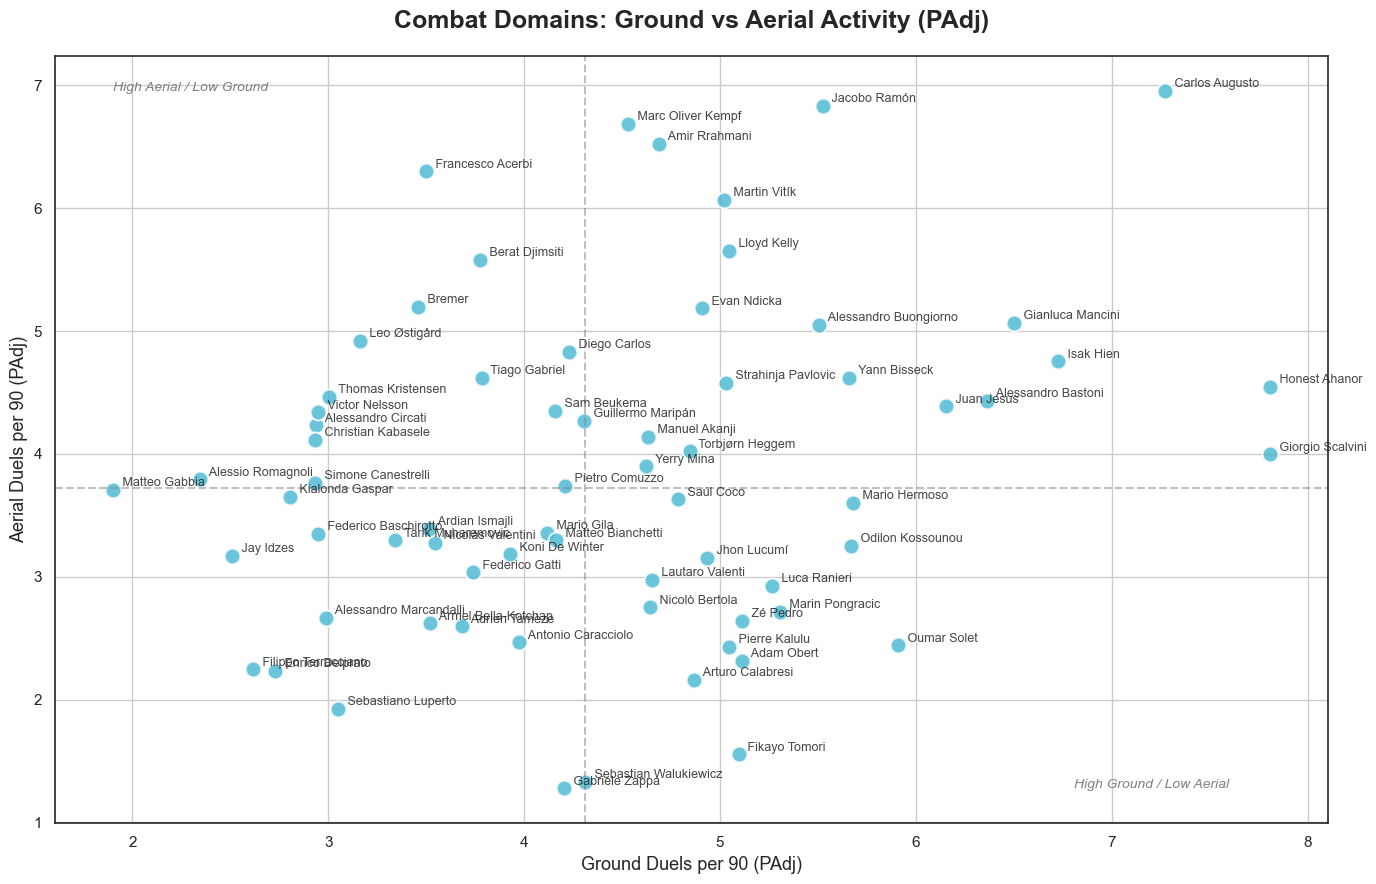

In [18]:
plt.figure(figsize=(14, 9))

plt.scatter(df['Ground Duels -total_padj'], df['Aerial Duels -total_padj'], 
            color='#45B7D1', s=130, alpha=0.8, edgecolor='white', linewidth=1.5)

for i, row in df.iterrows():
    plt.text(row['Ground Duels -total_padj'] + 0.03, row['Aerial Duels -total_padj'] + 0.03, 
             row['name'], fontsize=9, alpha=0.85)

plt.axvline(x=df['Ground Duels -total_padj'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=df['Aerial Duels -total_padj'].median(), color='gray', linestyle='--', alpha=0.5)

plt.title('Combat Domains: Ground vs Aerial Activity (PAdj)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Ground Duels per 90 (PAdj)', fontsize=13)
plt.ylabel('Aerial Duels per 90 (PAdj)', fontsize=13)

plt.text(df['Ground Duels -total_padj'].min(), df['Aerial Duels -total_padj'].max(), 'High Aerial / Low Ground', fontsize=10, color='gray', style='italic')
plt.text(df['Ground Duels -total_padj'].max() - 1, df['Aerial Duels -total_padj'].min(), 'High Ground / Low Aerial', fontsize=10, color='gray', style='italic')

plt.tight_layout()
plt.show()

## Dimensionality Reduction: Principal Component Analysis (PCA)

Our dataset currently consists of 9 distinct defensive metrics. While rich in information, high-dimensional data can suffer from multicollinearity (as seen in our correlation matrix) and make clustering algorithms less efficient. 

To solve this, we apply **Principal Component Analysis (PCA)**. PCA compresses these 9 variables into a smaller set of uncorrelated synthetic variables (Principal Components) while retaining as much of the original mathematical variance as possible. We will look at the Explained Variance and the Cumulative Variance (via a Scree Plot) to decide how many components to keep before applying our K-Means clustering.

In [19]:
df.columns

Index(['name', 'team', 'apps', 'mins', 'tackles', 'ints', 'pos won', 'blocks',
       'clearances', 'Ground Duels -total', 'Ground Duels %',
       'Aerial Duels -total', 'Aerial Duels %', 'team_poss', 'tackles_padj',
       'ints_padj', 'pos won_padj', 'blocks_padj', 'clearances_padj',
       'Ground Duels -total_padj', 'Aerial Duels -total_padj',
       'tackles_padj_z', 'ints_padj_z', 'pos won_padj_z', 'blocks_padj_z',
       'clearances_padj_z', 'Ground Duels -total_padj_z', 'Ground Duels %_z',
       'Aerial Duels -total_padj_z', 'Aerial Duels %_z'],
      dtype='object')

PCA Variance Summary Table:
--------------------------------------------------
Principal Component  Variance Explained (%)  Cumulative Variance (%)
                PC1                   29.15                    29.15
                PC2                   23.35                    52.50
                PC3                   12.25                    64.75
                PC4                   11.90                    76.65
                PC5                    9.18                    85.83
                PC6                    5.65                    91.48
                PC7                    4.10                    95.58
                PC8                    2.89                    98.47
                PC9                    1.53                   100.00
--------------------------------------------------


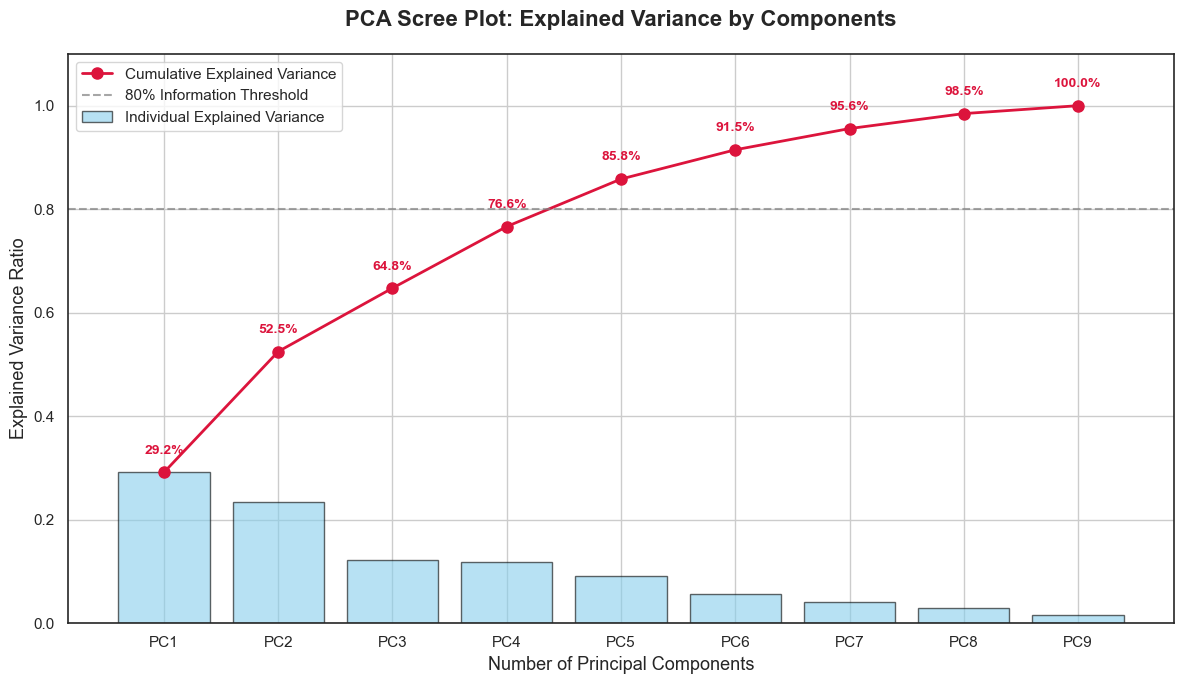

In [20]:
from sklearn.decomposition import PCA

# Set visual theme
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "0.15", "axes.linewidth": 1.2})

# Initialize and fit PCA on the standardized columns
pca = PCA()
pca.fit(df[z_columns])

# Extract variances
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Create a clean Summary Table (DataFrame)
pca_summary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Variance Explained (%)': np.round(explained_variance * 100, 2),
    'Cumulative Variance (%)': np.round(cumulative_variance * 100, 2)
})

print("PCA Variance Summary Table:")
print("-" * 50)
print(pca_summary.to_string(index=False))
print("-" * 50)

# Plotting the Scree Plot
plt.figure(figsize=(12, 7))

# Bar plot for individual explained variance
bars = plt.bar(range(1, len(explained_variance) + 1), explained_variance, 
               alpha=0.6, color='skyblue', label='Individual Explained Variance', edgecolor='black')

# Line plot for cumulative explained variance
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         marker='o', linestyle='-', color='crimson', linewidth=2, 
         markersize=8, label='Cumulative Explained Variance')

# Add a horizontal line to visualize a common threshold (e.g., 80%)
plt.axhline(y=0.80, color='gray', linestyle='--', alpha=0.7, label='80% Information Threshold')

# Aesthetics and formatting
plt.title('PCA Scree Plot: Explained Variance by Components', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Principal Components', fontsize=13)
plt.ylabel('Explained Variance Ratio', fontsize=13)
plt.xticks(range(1, len(explained_variance) + 1), [f'PC{i}' for i in range(1, len(explained_variance) + 1)])
plt.ylim(0, 1.1)
plt.legend(loc='best', fontsize=11)

# Add data labels on the cumulative line
for i, v in enumerate(cumulative_variance):
    plt.text(i + 1, v + 0.03, f"{v*100:.1f}%", ha='center', va='bottom', fontsize=10, color='crimson', fontweight='bold')

plt.tight_layout()
plt.show()

While standard statistical practice often targets an 80% cumulative variance threshold, context is key in sports analytics. By selecting **4 Principal Components**, we retain exactly **76.6%** of the original information. 

Adding a 5th component would push us past the 80% mark, but in football data, lower-variance components often capture statistical noise rather than genuine tactical profiles. Sticking to 4 components allows us to isolate the true defensive "signal" while ensuring our upcoming K-Means clusters remain highly distinct and easy to interpret for scouting and tactical analysis.

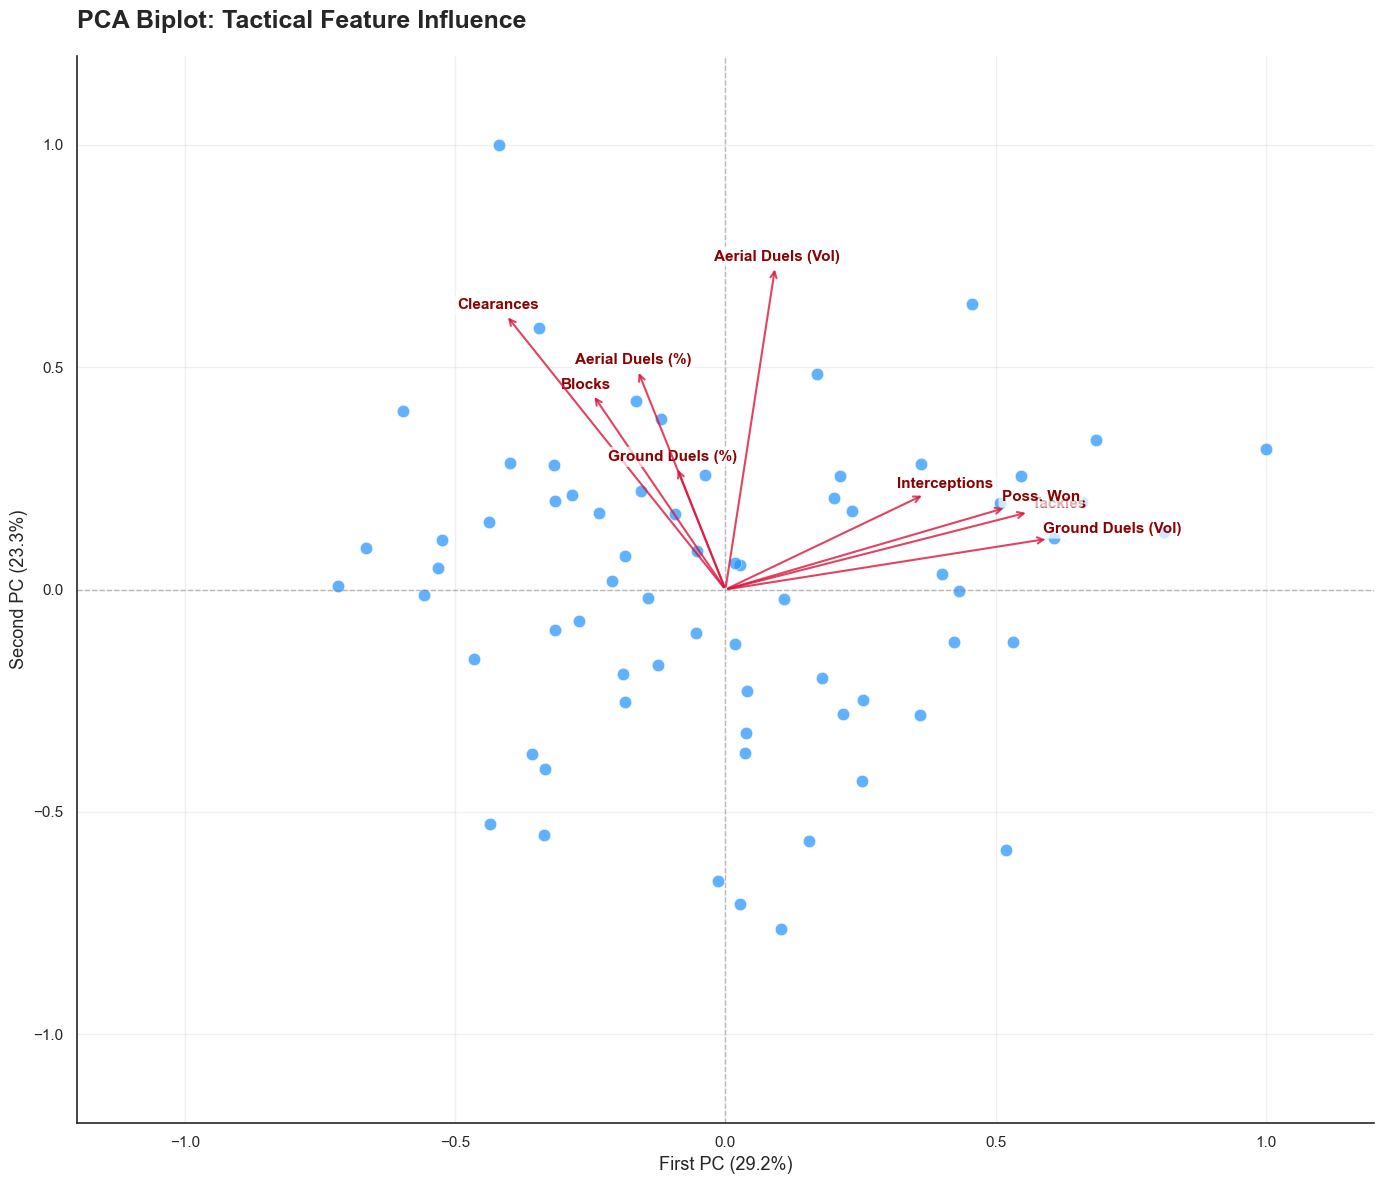

In [21]:
pca_final = PCA(n_components=4)
X_pca_final = pca_final.fit_transform(df[z_columns])

df_pca = pd.DataFrame(
    X_pca_final, 
    columns=['PC1', 'PC2', 'PC3', 'PC4'], 
    index=df.index
)

clean_features = [
    'Tackles', 'Interceptions', 'Poss. Won', 'Blocks', 'Clearances', 
    'Ground Duels (Vol)', 'Ground Duels (%)', 'Aerial Duels (Vol)', 'Aerial Duels (%)'
]

pc1_scaled = df_pca['PC1'] / np.max(np.abs(df_pca['PC1']))
pc2_scaled = df_pca['PC2'] / np.max(np.abs(df_pca['PC2']))

fig, ax = plt.subplots(figsize=(14, 12))

ax.scatter(pc1_scaled, pc2_scaled, color='dodgerblue', alpha=0.7, s=80, edgecolors='white', linewidth=0.5)

for i, feature in enumerate(clean_features):
    x_val = pca_final.components_[0, i]
    y_val = pca_final.components_[1, i]
    
    arrow_scale = 1.3
    ax.annotate(feature, 
                xy=(0, 0), 
                xytext=(x_val * arrow_scale, y_val * arrow_scale),
                arrowprops=dict(arrowstyle="<-", color='crimson', lw=1.5, alpha=0.8),
                color='darkred',
                fontsize=11,
                fontweight='bold',
                ha='center',
                va='center',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

# Estetica
ax.set_title("PCA Biplot: Tactical Feature Influence", loc="left", pad=20, fontsize=18, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0, color='grey', linestyle='--', linewidth=1, alpha=0.5)

var_pc1 = round(pca_final.explained_variance_ratio_[0] * 100, 1)
var_pc2 = round(pca_final.explained_variance_ratio_[1] * 100, 1)
ax.set_xlabel(f"First PC ({var_pc1}%)", fontsize=13)
ax.set_ylabel(f"Second PC ({var_pc2}%)", fontsize=13)

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The Biplot clearly decodes our first two Principal Components into two distinct tactical profiles:

* **PC1 (X-Axis) - The Ground Aggressor:** Driven by Tackles, Interceptions, and Ground Duels. Players on the far right are proactive, front-foot defenders.
* **PC2 (Y-Axis) - The Box Protector:** Driven by Aerial Duels, Clearances, and Blocks. Players high on this axis are traditional, deep-block dominators.

### PCA Loadings Matrix

The Loadings Table shows the exact mathematical weight (correlation) of each original metric on our 4 Principal Components. Positive and negative values indicate the direction of the relationship, confirming numerically what the Biplot displayed visually.

In [22]:
loadings_df = pd.DataFrame(
    pca_final.components_.T, 
    columns=['PC1', 'PC2', 'PC3', 'PC4'], 
    index=clean_features
)

print("PCA Loadings (Weights of each feature on the Principal Components):")

loadings_df.style.background_gradient(cmap='coolwarm').format("{:.3f}")

PCA Loadings (Weights of each feature on the Principal Components):


,PC1,PC2,PC3,PC4
Tackles,0.475,0.147,-0.417,0.185
Interceptions,0.313,0.182,0.328,-0.269
Poss. Won,0.449,0.159,0.311,-0.146
Blocks,-0.198,0.354,-0.457,-0.437
Clearances,-0.323,0.492,-0.075,-0.205
Ground Duels (Vol),0.551,0.105,-0.189,0.006
Ground Duels (%),-0.075,0.229,-0.239,0.738
Aerial Duels (Vol),0.073,0.576,0.006,0.015
Aerial Duels (%),-0.131,0.397,0.561,0.308


### Defining the Optimal K: Hierarchical Clustering

Before training our final K-Means model, we used Hierarchical Clustering (Ward's method) to explore the natural structure of the data and validate the optimal number of groups. By setting a cut-off line (threshold) at a distance of approximately 7, the dendrogram cleanly splits into 4 main branches. This provides the perfect mathematical justification for setting **K=4** in our K-Means algorithm.

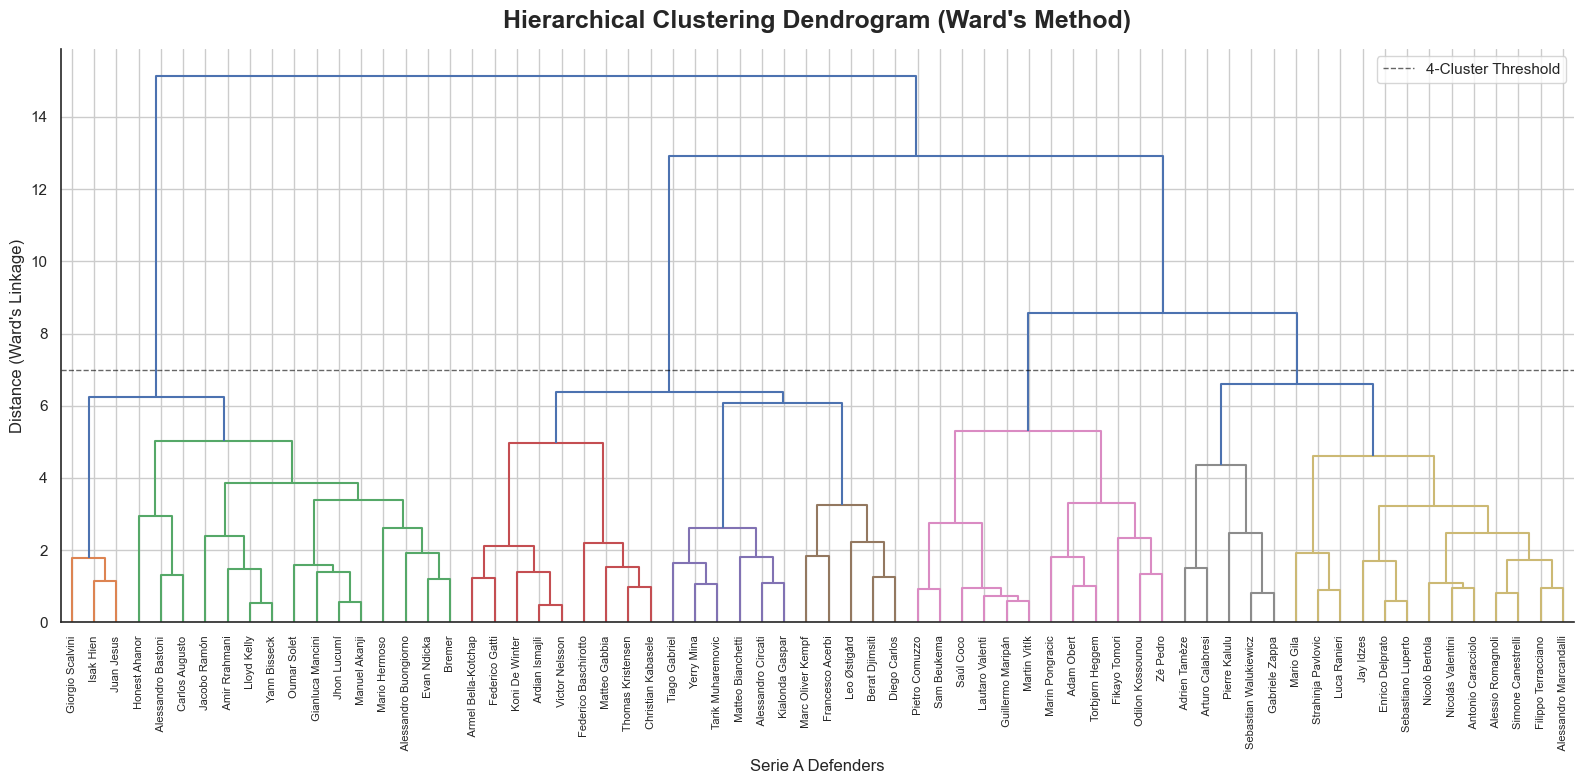

In [23]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

X_hierarchy = df_pca[['PC1', 'PC2', 'PC3', 'PC4']].values

distances = pdist(X_hierarchy, metric='euclidean')

linkage_matrix = linkage(distances, method='ward')

fig, ax = plt.subplots(figsize=(16, 8))

dendrogram(
    linkage_matrix,
    labels=df['name'].values,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=5.5, 
    ax=ax
)

cut_off_y = 7
ax.axhline(y=cut_off_y, color='black', linestyle='--', linewidth=1, alpha=0.6, label='4-Cluster Threshold')

ax.set_title("Hierarchical Clustering Dendrogram (Ward's Method)", fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel("Serie A Defenders", fontsize=12)
ax.set_ylabel("Distance (Ward's Linkage)", fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [24]:
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import KMeans

n_clusters = 4
X_data = df_pca[['PC1', 'PC2', 'PC3', 'PC4']].values

# Extract clusters from the dendrogram (cutting at the chosen threshold t=7.5)
hierarchical_clusters = fcluster(linkage_matrix, t=7, criterion='distance')

# Calculate the initial centroids based on these hierarchical groups
initial_centroids = []

for i in range(1, n_clusters + 1): 
    # Find the indices of the players assigned to this cluster
    indices = np.argwhere(hierarchical_clusters == i).flatten()
    
    # Calculate the mean of their Principal Components 
    cluster_centroid = X_data[indices].mean(axis=0)
    initial_centroids.append(cluster_centroid)

initial_centroids = np.array(initial_centroids)

print("Initial Centroids calculated from Dendrogram:")
print(np.round(initial_centroids, 3))
print("-" * 50)

# Initialize K-Means with our pre-calculated hierarchical centroids
kmeans = KMeans(n_clusters=n_clusters, init=initial_centroids, n_init=1, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_data)

print("Players per Cluster:")
print(df['Cluster'].value_counts().sort_index())

Initial Centroids calculated from Dendrogram:
[[ 1.958  0.83   0.356  0.162]
 [-1.578  0.975  0.204 -0.023]
 [ 0.317 -0.453 -1.175 -0.776]
 [-0.415 -1.612  0.2    0.381]]
--------------------------------------------------
Players per Cluster:
Cluster
0    17
1    22
2    13
3    16
Name: count, dtype: int64


In [25]:
from sklearn.metrics import silhouette_score

X_data = df_pca[['PC1', 'PC2', 'PC3', 'PC4']].values

cluster_labels = df['Cluster']

# 3. Calculate the Silhouette Score
# We use 'euclidean' distance because K-Means minimizes euclidean distances
sil_score = silhouette_score(X_data, cluster_labels, metric='euclidean', random_state=42)

print(" CLUSTER VALIDATION ")
print(f"Final Silhouette Score (K=4): {sil_score:.4f}")

 CLUSTER VALIDATION 
Final Silhouette Score (K=4): 0.2257


### Tactical Territories: Visualizing Clusters in 2D

To get a clear look at our tactical segmentation, we projected the players onto a 2D plane using the first two Principal Components (PC1 and PC2). The shaded areas (Convex Hulls) map out the tactical "footprints" of each cluster.

**A quick note on the overlapping zones:** You might notice that some group boundaries bleed into each other (like the green and orange territories). This doesn't mean the K-Means algorithm failed to separate them. It's simply a side effect of dimension reduction. The model actually grouped these players using **4 dimensions (PC1 through PC4)**, but we are only visualizing two of them here. We are essentially looking at a "2D shadow" of a mathematical separation that is much cleaner and more strictly defined in its true 4D space.

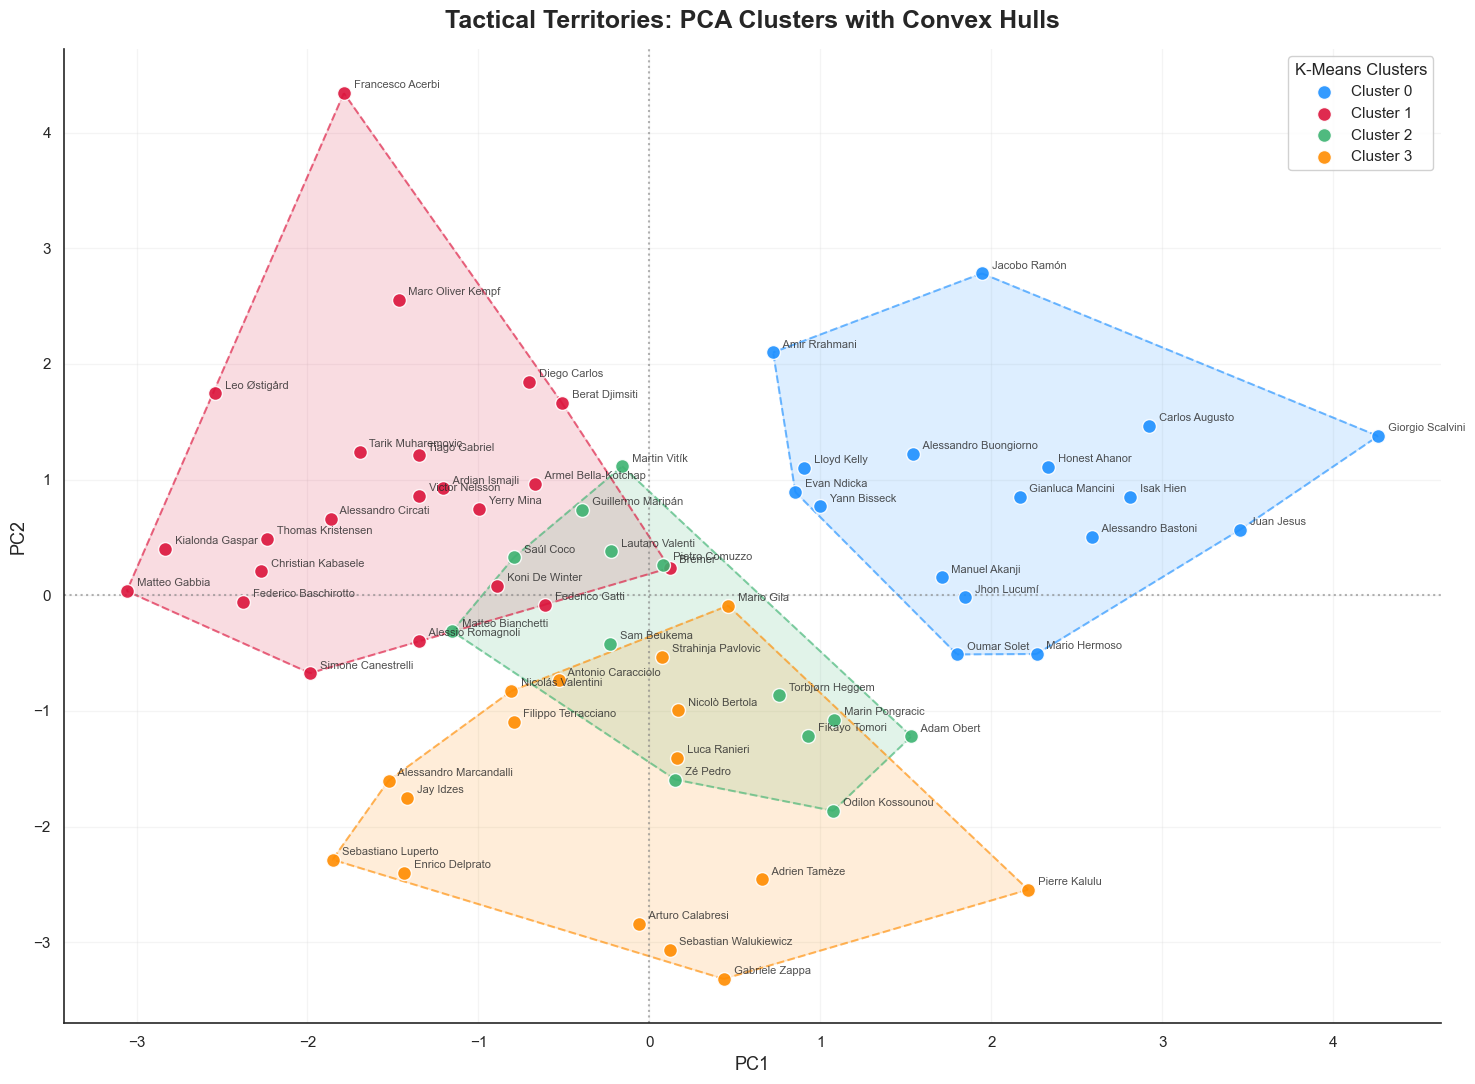

In [26]:
from scipy.spatial import ConvexHull

plt.figure(figsize=(15, 11))

colors = ['dodgerblue', 'crimson', 'mediumseagreen', 'darkorange']
n_clusters = 4

for i in range(n_clusters):
    cluster_points = df_pca[df['Cluster'] == i][['PC1', 'PC2']].values
    
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                c=colors[i], label=f'Cluster {i}', s=100, edgecolors='white', alpha=0.9, zorder=3)
    
    if len(cluster_points) >= 3:
        hull = ConvexHull(cluster_points)
        plt.fill(cluster_points[hull.vertices, 0], cluster_points[hull.vertices, 1],
                 color=colors[i], alpha=0.15, zorder=1)
        for simplex in hull.simplices:
            plt.plot(cluster_points[simplex, 0], cluster_points[simplex, 1], 
                     color=colors[i], linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)

for i, player in enumerate(df['name']):
    plt.text(df_pca['PC1'].iloc[i] + 0.04, df_pca['PC2'].iloc[i] + 0.04, 
             player, fontsize=8, alpha=0.8, zorder=4)


plt.axhline(0, color='grey', linestyle=':', alpha=0.6)
plt.axvline(0, color='grey', linestyle=':', alpha=0.6)

plt.title("Tactical Territories: PCA Clusters with Convex Hulls", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("PC1", fontsize=13)
plt.ylabel("PC2", fontsize=13)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(title="K-Means Clusters", loc='upper right', fontsize=11, framealpha=0.9)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Cluster Profiling

Now that our algorithm has grouped the players, we need to translate these mathematical clusters back into actual football terms. 

To understand the real-world playing style of each group, we calculated their average performance across our core metrics and compared it directly to the Serie A baseline. This generates concrete **Scouting Profiles**, showing exactly where each tactical family overperforms or underperforms compared to the league average.

In [27]:
from IPython.display import display

raw_target_metrics = [
    'tackles_padj', 'ints_padj', 'pos won_padj', 'blocks_padj', 'clearances_padj', 
    'Ground Duels -total_padj', 'Ground Duels %', 
    'Aerial Duels -total_padj', 'Aerial Duels %'
]

def get_raw_cluster_stats(cluster_df, full_df, metrics):
    # Calculate means and standard deviations for the specific cluster
    cluster_stats = cluster_df[metrics].mean().to_frame("Cluster Avg")
    
    # Calculate overall league averages for comparison
    league_stats = full_df[metrics].mean().to_frame("League Avg")
    
    # Combine into a single profile table
    profile = cluster_stats.join(league_stats)
    
    # Calculate the absolute difference
    profile['Difference'] = profile['Cluster Avg'] - profile['League Avg']
    
    # Calculate the percentage difference for better context
    profile['% vs League'] = (profile['Difference'] / profile['League Avg'] * 100).round(1).astype(str) + '%'
    
    return profile.round(2)


for i in range(4):
    print(f"\n" + "="*50)
    print(f"SCOUTING PROFILE: CLUSTER {i}")
    print("="*50)
    
    
    profile_table = get_raw_cluster_stats(df[df['Cluster'] == i], df, raw_target_metrics)
    display(profile_table)
    
    # Print top 5 
    top_players = df[df['Cluster'] == i]['name'].head(5).tolist()
    print(f"Representative Players: {', '.join(top_players)}")


SCOUTING PROFILE: CLUSTER 0


,Cluster Avg,League Avg,Difference,% vs League
tackles_padj,2.05,1.54,0.51,33.3%
ints_padj,1.49,1.13,0.36,32.0%
pos won_padj,4.95,3.66,1.29,35.3%
blocks_padj,0.57,0.67,-0.09,-13.9%
clearances_padj,4.39,4.80,-0.41,-8.5%
Ground Duels -total_padj,5.95,4.41,1.54,34.8%
Ground Duels %,55.45,54.78,0.67,1.2%
Aerial Duels -total_padj,4.78,3.83,0.95,24.9%
Aerial Duels %,60.21,57.91,2.30,4.0%


Representative Players:  Isak Hien,  Jhon Lucumí,  Giorgio Scalvini,  Oumar Solet,  Lloyd Kelly

SCOUTING PROFILE: CLUSTER 1


,Cluster Avg,League Avg,Difference,% vs League
tackles_padj,1.16,1.54,-0.37,-24.3%
ints_padj,1.04,1.13,-0.09,-7.6%
pos won_padj,3.17,3.66,-0.49,-13.4%
blocks_padj,0.79,0.67,0.12,18.7%
clearances_padj,6.01,4.80,1.21,25.3%
Ground Duels -total_padj,3.36,4.41,-1.05,-23.9%
Ground Duels %,56.13,54.78,1.34,2.5%
Aerial Duels -total_padj,4.23,3.83,0.39,10.3%
Aerial Duels %,64.37,57.91,6.47,11.2%


Representative Players:  Armel Bella-Kotchap,  Bremer,  Federico Gatti,  Koni De Winter,  Marc Oliver Kempf

SCOUTING PROFILE: CLUSTER 2


,Cluster Avg,League Avg,Difference,% vs League
tackles_padj,1.77,1.54,0.23,15.1%
ints_padj,1.04,1.13,-0.09,-7.9%
pos won_padj,3.32,3.66,-0.34,-9.3%
blocks_padj,0.84,0.67,0.18,26.5%
clearances_padj,4.69,4.80,-0.10,-2.1%
Ground Duels -total_padj,4.80,4.41,0.39,8.9%
Ground Duels %,52.80,54.78,-1.98,-3.6%
Aerial Duels -total_padj,3.45,3.83,-0.38,-10.0%
Aerial Duels %,48.93,57.91,-8.98,-15.5%


Representative Players:  Marin Pongracic,  Adam Obert,  Torbjørn Heggem,  Lautaro Valenti,  Pietro Comuzzo

SCOUTING PROFILE: CLUSTER 3


,Cluster Avg,League Avg,Difference,% vs League
tackles_padj,1.32,1.54,-0.22,-14.3%
ints_padj,0.93,1.13,-0.19,-17.1%
pos won_padj,3.23,3.66,-0.42,-11.6%
blocks_padj,0.45,0.67,-0.22,-32.5%
clearances_padj,3.65,4.80,-1.15,-24.0%
Ground Duels -total_padj,3.91,4.41,-0.50,-11.3%
Ground Duels %,53.84,54.78,-0.95,-1.7%
Aerial Duels -total_padj,2.59,3.83,-1.24,-32.5%
Aerial Duels %,53.86,57.91,-4.04,-7.0%


Representative Players:  Mario Gila,  Adrien Tamèze,  Pierre Kalulu,  Filippo Terracciano,  Arturo Calabresi


### Visualizing the Tactical DNA: Cluster Comparison

To provide a final, intuitive comparison of our 4 defensive profiles, we plot the average values of our 9 core metrics side-by-side. By visualizing these averages on their original scale, we can clearly see the tactical tradeoffs each type of defender makes.

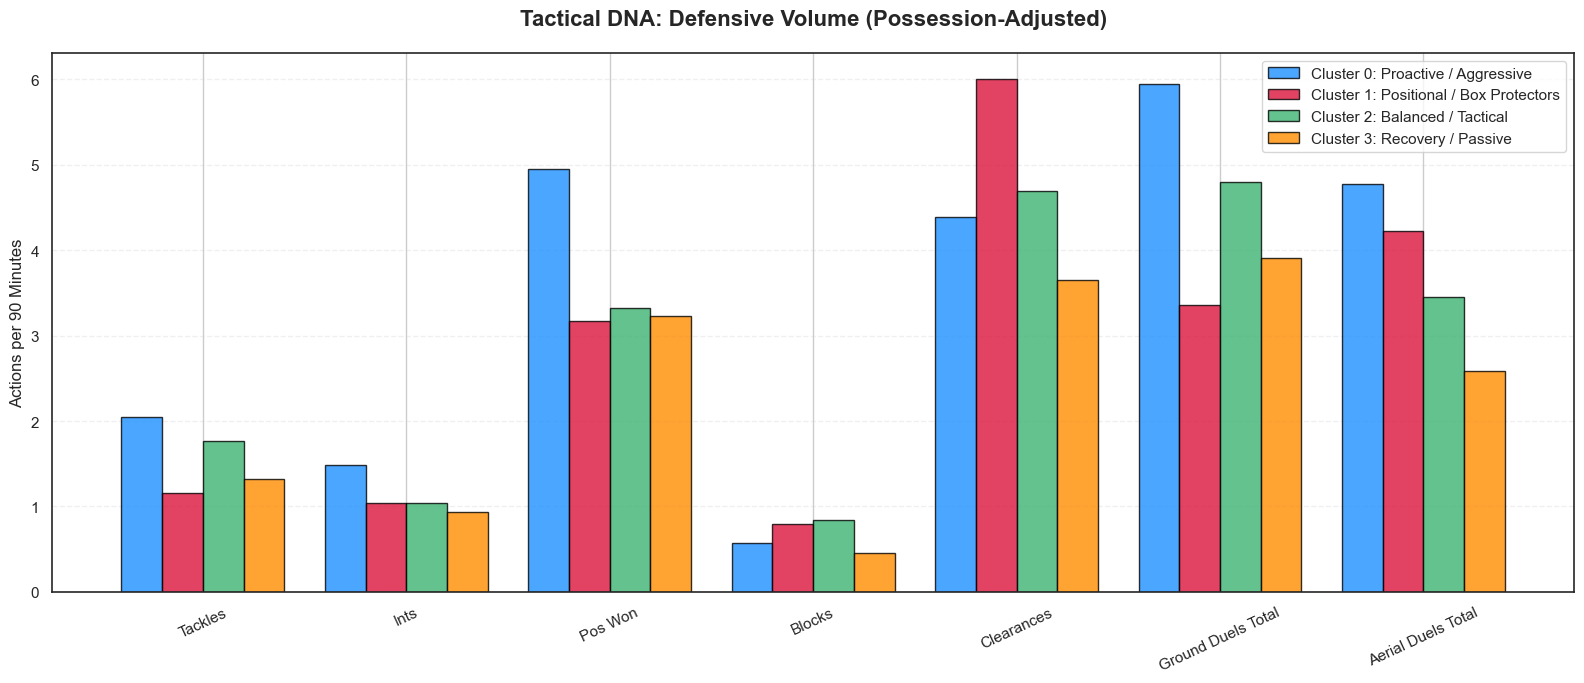

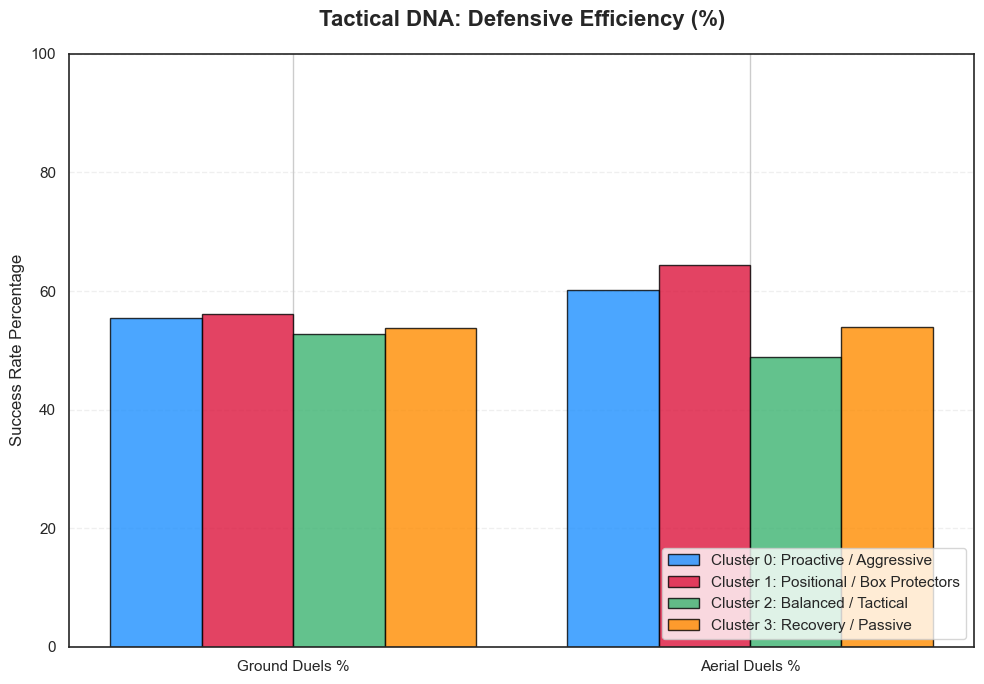

In [28]:
# Separate the metrics by scale
volume_metrics = [
    'tackles_padj', 'ints_padj', 'pos won_padj', 'blocks_padj', 
    'clearances_padj', 'Ground Duels -total_padj', 'Aerial Duels -total_padj'
]
percentage_metrics = ['Ground Duels %', 'Aerial Duels %']

# Store results for plotting
plot_data = {i: get_raw_cluster_stats(df[df['Cluster'] == i], df, raw_target_metrics) for i in range(4)}

# Define colors and labels
colors = ['dodgerblue', 'crimson', 'mediumseagreen', 'darkorange']
cluster_labels = [
    'Cluster 0: Proactive / Aggressive',
    'Cluster 1: Positional / Box Protectors',
    'Cluster 2: Balanced / Tactical',
    'Cluster 3: Recovery / Passive'
]

# Helper function to clean labels for the X-axis
def clean(label):
    return label.replace('_padj', '').replace('-', '').title()

# ==========================================
# CHART 1: DEFENSIVE VOLUME (7 METRICS)
# ==========================================
fig, ax1 = plt.subplots(figsize=(16, 7))
x = np.arange(len(volume_metrics))
width = 0.2

for i in range(4):
    means = plot_data[i].loc[volume_metrics, 'Cluster Avg'].values
    ax1.bar(x + (i - 1.5) * width, means, width, label=cluster_labels[i], color=colors[i], edgecolor='black', alpha=0.8)

ax1.set_title('Tactical DNA: Defensive Volume (Possession-Adjusted)', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Actions per 90 Minutes', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels([clean(l) for l in volume_metrics], rotation=25)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# CHART 2: DEFENSIVE EFFICIENCY (2 METRICS)
# ==========================================
fig, ax2 = plt.subplots(figsize=(10, 7))
x_pct = np.arange(len(percentage_metrics))

for i in range(4):
    means_pct = plot_data[i].loc[percentage_metrics, 'Cluster Avg'].values
    ax2.bar(x_pct + (i - 1.5) * width, means_pct, width, label=cluster_labels[i], color=colors[i], edgecolor='black', alpha=0.8)

ax2.set_title('Tactical DNA: Defensive Efficiency (%)', fontsize=16, fontweight='bold', pad=20)
ax2.set_ylabel('Success Rate Percentage', fontsize=12)
ax2.set_ylim(0, 100) # Fixed scale for percentages
ax2.set_xticks(x_pct)
ax2.set_xticklabels([clean(l) for l in percentage_metrics])
ax2.legend(loc='lower right')
ax2.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

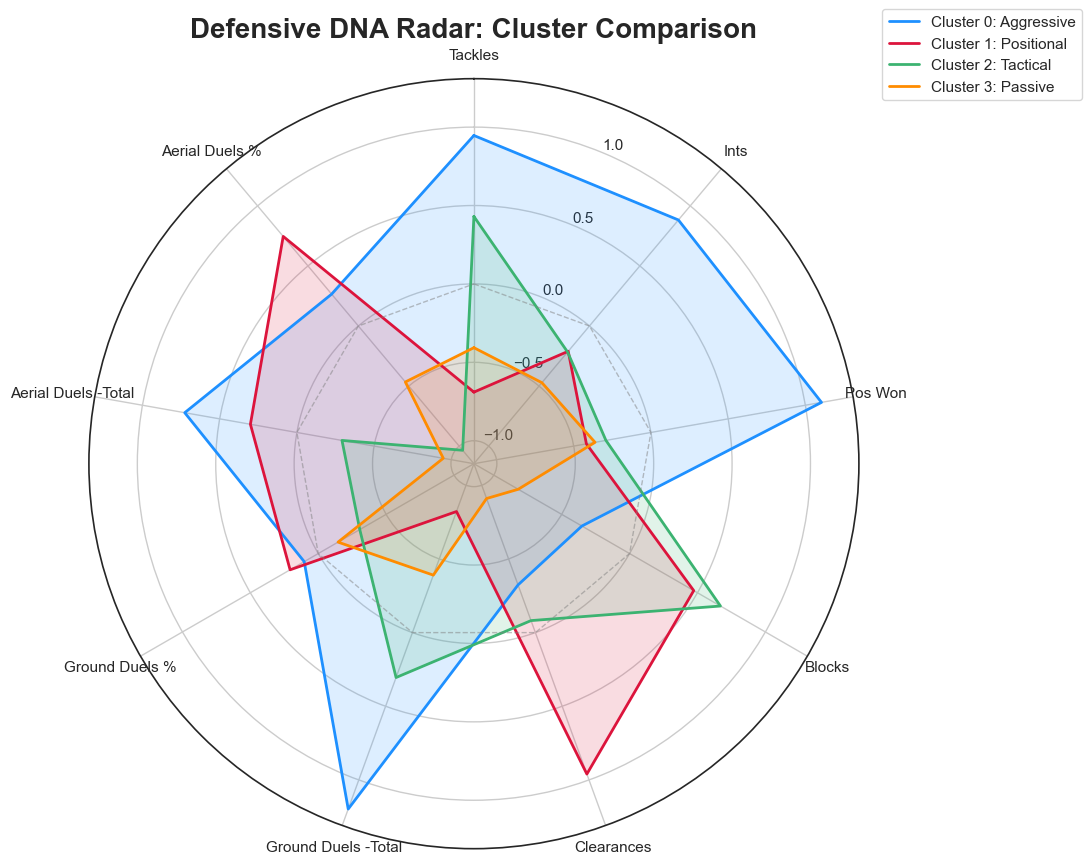

In [29]:
# Prepare data for Radar Chart (Using Z-scores for maximum contrast)

radar_features = z_columns
labels = [f.replace('_padj_z', '').replace('_z', '').title() for f in radar_features]
num_vars = len(labels)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the circle

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Define colors 
colors = ['dodgerblue', 'crimson', 'mediumseagreen', 'darkorange']
cluster_names = ['Cluster 0: Aggressive', 'Cluster 1: Positional', 'Cluster 2: Tactical', 'Cluster 3: Passive']

for i in range(4):
    # Calculate average Z-scores for the cluster
    values = df[df['Cluster'] == i][radar_features].mean().values.tolist()
    values += values[:1] # Close the circle
    
    ax.plot(angles, values, color=colors[i], linewidth=2, label=cluster_names[i])
    ax.fill(angles, values, color=colors[i], alpha=0.15)

# Fix axis labels
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)

# Add a reference circle at 0 (League Average)
ax.plot(angles, [0]*len(angles), color='grey', linestyle='--', linewidth=1, alpha=0.5)

# Aesthetics
ax.set_title('Defensive DNA Radar: Cluster Comparison', size=20, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

### Cluster Interpretation: Defensive Profiles

By analyzing the volume and efficiency metrics, we can translate our four mathematical clusters into practical tactical profiles. Here is the breakdown of the playing styles:

**🔵 Cluster 0: High-Volume Ground Defenders**
* **Data Overview:** This group is well above the league average in Tackles (+33%), Interceptions (+32%), and Ground Duels (+35%). They have lower numbers in blocks and clearances.
* **Tactical Profile:** These defenders play a proactive style. Instead of dropping deep to protect the penalty area, they step up to engage opponents and try to win the ball back early.
* **Key Players:** Scalvini, Hien, Lucumí.

**🔴 Cluster 1: Penalty Box Defenders**
* **Data Overview:** This group leads the league in Clearances (+25%) and Blocks (+19%). They also have a very high aerial win rate (64%, which is 11% above average). Their tackling volume is significantly lower (-24%).
* **Tactical Profile:** These are traditional, positional center-backs. They excel at absorbing pressure, holding the defensive line, and clearing the ball from the penalty area.
* **Key Players:** Bremer, Gatti, Bella-Kotchap.

**🟢 Cluster 2: Ground-Focused Defenders**
* **Data Overview:** They have solid numbers on the ground (Tackles +15%, Blocks +26%), but show a clear weakness in the air, with a significant drop in both aerial volume (-10%) and aerial win rate (-15.5%).
* **Tactical Profile:** These players are comfortable engaging opponents on the ground, often profiling as wide center-backs in a three-man defense. However, they struggle in physical aerial duels against tall forwards.
* **Key Players:** Heggem, Tomori, Comuzzo.

**🟠 Cluster 3: Low-Volume Recovery Defenders**
* **Data Overview:** This group sits below the league average in almost all volume metrics, with major drops in Blocks (-32%), Aerial Duels (-32%), and Clearances (-24%).
* **Tactical Profile:** A low volume of defensive actions doesn't mean poor defending. These players usually rely on their pace, positioning, and ability to cover open space rather than engaging in direct physical duels.
* **Key Players:** Kalulu, Gila, Tamèze.

## Tactical Identity: Soft Clustering (Membership %)

Now that we have defined the four core tactical profiles, we must acknowledge a reality of modern football: players are rarely strictly one thing. A defender might be primarily a "Penalty Box Defender" but also possess traits of a "Proactive Defender".

To capture this nuance, we shift from Hard Clustering to **Soft Clustering**. We calculate the inverse distance of each player to all four K-Means centroids, transforming these distances into a **Cluster Membership Percentage**. This allows us to quantify a player's "Tactical DNA" and easily distinguish between pure specialists and versatile hybrid defenders.

In [36]:
from scipy.spatial import distance

# Membership percentages based on distance to centroids
def get_memberships(row, centroids):
    # Euclidean distance from the player to all 4 centroids
    dists = [distance.euclidean(row, c) for c in centroids]
    
    # Invert the distance (closer = higher percentage)
    # Added a tiny constant to prevent division by zero
    inv_dists = [1.0 / (d + 1e-10) for d in dists]
    total = sum(inv_dists)
    
    # Return percentages rounded to 1 decimal place
    return [round((d / total) * 100, 1) for d in inv_dists]

# Centroids from the trained model
centroids = kmeans.cluster_centers_
pca_features = ['PC1', 'PC2', 'PC3', 'PC4']

membership_data = df_pca[pca_features].apply(lambda x: get_memberships(x, centroids), axis=1)

for i in range(4):
    df[f'Cluster_{i}_%'] = [m[i] for m in membership_data]

display_cols = ['name', 'team', 'Cluster', 'Cluster_0_%', 'Cluster_1_%', 'Cluster_2_%', 'Cluster_3_%']
display(df[display_cols])

,name,team,Cluster,Cluster_0_%,Cluster_1_%,Cluster_2_%,Cluster_3_%
0,Isak Hien,Atalanta,0,45.0,15.4,23.4,16.3
1,Jhon Lucumí,Bologna,0,43.5,14.1,24.8,17.6
2,Giorgio Scalvini,Atalanta,0,37.0,18.9,24.6,19.4
3,Oumar Solet,Udinese,0,37.6,16.1,21.9,24.3
4,Lloyd Kelly,Juventus,0,41.2,21.0,20.5,17.3
...,...,...,...,...,...,...,...
63,Sebastiano Luperto,Cremonese,3,14.2,22.1,24.7,39.0
64,Matteo Bianchetti,Cremonese,2,16.5,26.5,30.9,26.2
65,Martin Vitík,Bologna,2,20.8,25.9,35.3,18.1
66,Kialonda Gaspar,Lecce,1,16.5,36.4,23.7,23.4


## Tactical Extremes: Specialists vs Hybrids

By looking at the maximum percentage a player has in any single cluster, we can identify two opposite profiles:
* **Tactical Specialists:** Players with a very high percentage in a single cluster. They are the absolute reference points for their specific defensive style.
* **Hybrid Profiles:** Players with their percentages evenly distributed across multiple clusters. They lack a single dominant trait, making them highly versatile and unpredictable.

In [40]:
# Calculate the maximum percentage for each player
perc_cols = ['Cluster_0_%', 'Cluster_1_%', 'Cluster_2_%', 'Cluster_3_%']
df['Max_Percentage'] = df[perc_cols].max(axis=1)

# TOP 5 TACTICAL SPECIALISTS
print("TOP 5 TACTICAL SPECIALISTS")
print("Players who perfectly embody a single tactical profile.\n")

specialists = df.sort_values(by='Max_Percentage', ascending=False)
display(specialists[['name', 'team', 'Cluster', 'Max_Percentage']].head(5).style.background_gradient(cmap='Greens', subset=['Max_Percentage']))

print("\n" + "-"*75 + "\n")

# TOP 5 HYBRID PROFILES
print("TOP 5 HYBRID PROFILES")
print("Players with evenly distributed traits across multiple defensive styles.\n")

hybrids = df.sort_values(by='Max_Percentage', ascending=True)
display_cols = ['name', 'team', 'Cluster', 'Max_Percentage'] + perc_cols
display(hybrids[display_cols].head(5).style.background_gradient(cmap='YlOrRd', subset=['Max_Percentage']))

TOP 5 TACTICAL SPECIALISTS
Players who perfectly embody a single tactical profile.



,name,team,Cluster,Max_Percentage
35,Gianluca Mancini,Roma,0,72.700000
45,Tarik Muharemovic,Sassuolo,1,62.100000
46,Victor Nelsson,Hellas Verona,1,56.900000
44,Ardian Ismajli,Torino,1,52.500000
56,Thomas Kristensen,Udinese,1,50.900000



---------------------------------------------------------------------------

TOP 5 HYBRID PROFILES
Players with evenly distributed traits across multiple defensive styles.



,name,team,Cluster,Max_Percentage,Cluster_0_%,Cluster_1_%,Cluster_2_%,Cluster_3_%
7,Mario Gila,Lazio,3,28.300000,26.300000,23.200000,22.200000,28.300000
13,Bremer,Juventus,1,28.400000,24.600000,28.400000,22.900000,24.100000
5,Marin Pongracic,Fiorentina,2,29.400000,24.400000,19.200000,29.400000,27.100000
64,Matteo Bianchetti,Cremonese,2,30.900000,16.500000,26.500000,30.900000,26.200000
50,Strahinja Pavlovic,Milan,3,31.700000,20.100000,21.200000,27.100000,31.700000


The results highlight **Gianluca Mancini** as the ultimate tactical specialist, dominating his proactive profile with a 72.7% membership score. Conversely, defenders like **Mario Gila** and **Bremer** emerge as the ultimate hybrid profiles, exhibiting an almost perfectly equal distribution across all four tactical styles (ranging between 22% and 28%). This mathematically quantifies the difference between players built for highly specific defensive tasks and versatile athletes capable of adapting to multiple tactical systems.

## LOF : Local Outlier Factor

While K-Means forces every player into a cluster, it can hide players with highly unusual, hybrid playing styles. To detect players who are completely isolated in their specific tactical niche, we apply the **Local Outlier Factor (LOF)**.

LOF measures the local density deviation of a given data point with respect to its neighbors. Players with a **lof_label = -1** represent **local tactical anomalies**. In particular, players with higher **LOF scores** exhibit **strong local isolation**, indicating tactical profiles that differ substantially even from the players most similar to them.

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
import pandas as pd

def apply_lof(data, features, n_neighbors=10, contamination=0.05):
    df_lof = data.copy()
    X = df_lof[features].copy()

    # Scaling the principal components
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Initialize the LOF model
    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination
    )

    # Fit & predict
    df_lof["lof_label"] = lof.fit_predict(X_scaled)  # -1 for outlier, 1 for inlier
    df_lof["lof_score"] = -lof.negative_outlier_factor_

    return df_lof

# Combine PCA columns with names/clusters before applying LOF
df_combined = df_pca[['PC1', 'PC2', 'PC3', 'PC4']].copy()
df_combined['name'] = df['name']
df_combined['Cluster'] = df['Cluster']

# Apply LOF to our 4 Principal Components using the combined dataframe
pca_features = ["PC1", "PC2", "PC3", "PC4"]
df_lof_results = apply_lof(df_combined, pca_features, n_neighbors=10, contamination=0.05)

# Extract and visualize the anomalies
outliers_lof = df_lof_results[df_lof_results["lof_label"] == -1]

print(" LOCAL TACTICAL ANOMALIES (LOF) ")
if outliers_lof.empty:
    print("No local outliers detected with the current contamination rate.")
else:
    # Sort by LOF score descending (highest score = most isolated)
    display_cols = ["name", "Cluster", "lof_score"]
    print(outliers_lof[display_cols].sort_values(by="lof_score", ascending=False).round(3).to_string(index=False))

 LOCAL TACTICAL ANOMALIES (LOF) 
             name  Cluster  lof_score
 Francesco Acerbi        1      1.534
 Giorgio Scalvini        0      1.457
 Arturo Calabresi        3      1.362
    Honest Ahanor        0      1.347


### Visualizing the Outlier Radar Profiles

After identifying our top local anomalies using the LOF algorithm, we can plot their specific standardized metrics on a Radar Chart. By comparing their individual shapes to the baseline (League Average = 0), we can visually decode exactly what makes their playing style so unique.

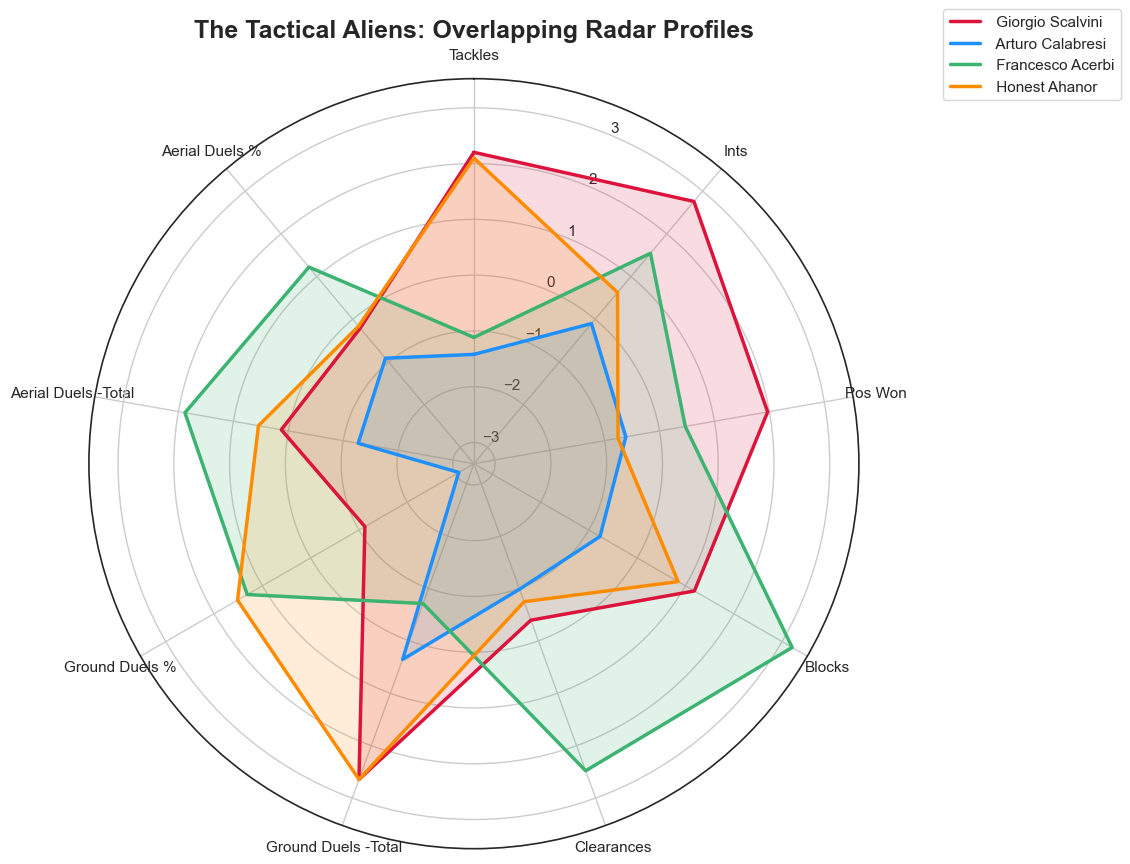

In [32]:
alien_names = [' Francesco Acerbi', ' Giorgio Scalvini', ' Arturo Calabresi', ' Honest Ahanor']
df_aliens = df[df['name'].isin(alien_names)]

radar_features = z_columns
labels = [f.replace('_padj_z', '').replace('_z', '').title() for f in radar_features]
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] 

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

colors = ['crimson', 'dodgerblue', 'mediumseagreen', 'darkorange']

for i, (index, row) in enumerate(df_aliens.iterrows()):
    player_name = row['name']
    
    values = row[radar_features].values.tolist()
    values += values[:1] 
    
    ax.plot(angles, values, color=colors[i], linewidth=2.5, label=player_name)
    
    ax.fill(angles, values, color=colors[i], alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)

ax.set_title('The Tactical Aliens: Overlapping Radar Profiles', size=18, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)

plt.show()

### Why are these players so unique?

* **Giorgio Scalvini:** His shape spikes at the top (Tackles, Interceptions, Possession Won). He is an extremely proactive defender who pushes forward to win the ball, but rarely stays back to clear it.
* **Francesco Acerbi:** The exact opposite of Scalvini. His shape is huge at the bottom (Clearances, Blocks, Aerial Duels). He is a traditional center-back who stays deep to protect the penalty area.
* **Honest Ahanor:** His shape points straight down to Ground Duels. He is very active on the ground but almost never engages in aerial duels, making him highly specialized.
* **Arturo Calabresi:** His shape is very small and stays close to the center. This means his defensive actions are very low across all metrics. He is a passive defender who likely relies on positioning and covering space rather than making direct tackles.

## Player Similarity: Finding Tactical Clones

In professional scouting, one of the most critical tasks is finding a "tactical replacement": a player capable of performing the same role as a departing star, often at a significantly lower cost. 

To achieve this, I developed a **Similarity Engine** based on **Euclidean Distance** within the 4D Principal Component space. Unlike standard statistical comparisons, this engine identifies players who share the same tactical "DNA" by measuring their proximity in the PCA-transformed feature space.

### The Methodology:
* **Benchmark Selection:** We select an elite "target" player (e.g., Bastoni, Bremer, or Scalvini) to define the desired defensive profile.
* **N-Dimensional Search:** The engine calculates the mathematical distance between the target and every other defender in the league.
* **Expanded Discovery (Top 7):** By looking at the top 5 closest matches, we move beyond obvious high-value targets to identify **"Hidden Gems"**—undervalued players in mid-table clubs who are statistically nearly identical to elite stars.
* **Radar Verification:** We use comparative Radar Charts to visually confirm that the suggested clones mirror the target's strengths and playing style.

This data-driven approach transforms scouting from a subjective process into a **budget-efficient strategy**, uncovering high-value replacements that traditional observation might miss.


——————————————————————————————————————————————————————————————————————
 SCOUTING: BALL-PLAYING SPECIALIST
 TARGET:  Alessandro Bastoni
——————————————————————————————————————————————————————————————————————


,name,team,Cluster,Cluster_0_%,Cluster_1_%,Cluster_2_%,Cluster_3_%,Distance
47,Carlos Augusto,Inter,0,41.500000,18.600000,20.700000,19.200000,1.306249
3,Oumar Solet,Udinese,0,37.600000,16.100000,21.900000,24.300000,1.415807
35,Gianluca Mancini,Roma,0,72.700000,8.500000,10.200000,8.700000,1.614211
18,Manuel Akanji,Inter,0,49.900000,13.300000,20.700000,16.200000,1.687973
36,Yann Bisseck,Inter,0,40.800000,20.300000,19.800000,19.100000,1.689032
4,Lloyd Kelly,Juventus,0,41.200000,21.000000,20.500000,17.300000,1.967682
1,Jhon Lucumí,Bologna,0,43.500000,14.100000,24.800000,17.600000,2.119922


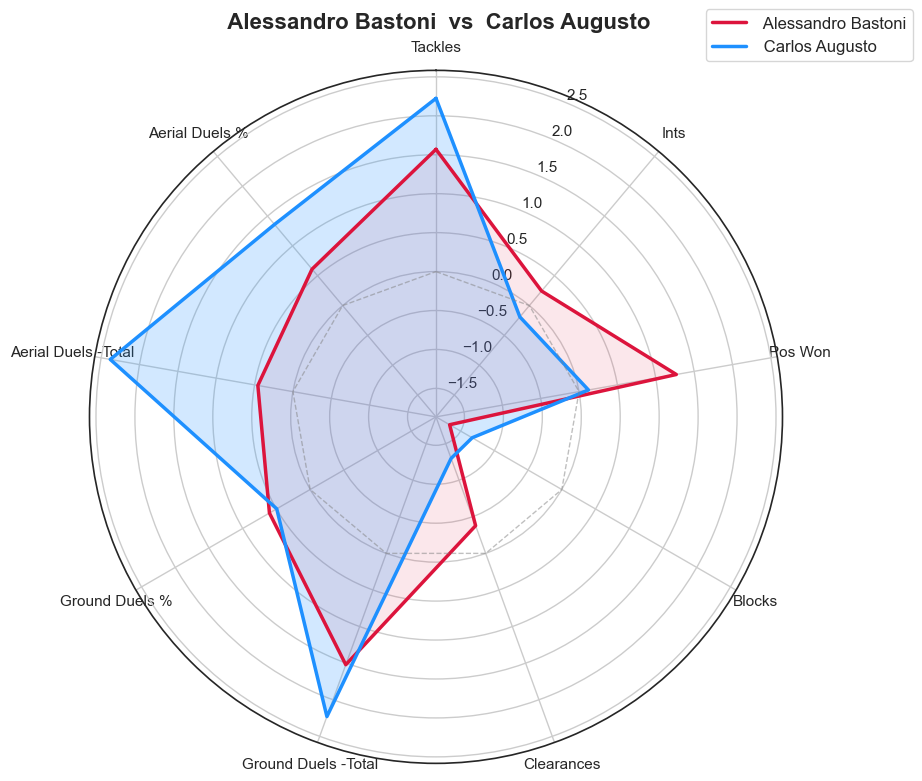


——————————————————————————————————————————————————————————————————————
 SCOUTING: TRADITIONAL BOX PROTECTOR
 TARGET:  Bremer
——————————————————————————————————————————————————————————————————————


,name,team,Cluster,Cluster_0_%,Cluster_1_%,Cluster_2_%,Cluster_3_%,Distance
8,Evan Ndicka,Roma,0,36.400000,23.800000,19.900000,19.900000,1.204245
22,Federico Gatti,Juventus,1,20.400000,32.400000,20.400000,26.800000,1.299404
36,Yann Bisseck,Inter,0,40.800000,20.300000,19.800000,19.100000,1.474122
4,Lloyd Kelly,Juventus,0,41.200000,21.000000,20.500000,17.300000,1.516971
23,Koni De Winter,Milan,1,19.200000,34.900000,19.100000,26.800000,1.560561
30,Antonio Caracciolo,Pisa,3,13.600000,21.700000,30.700000,34.000000,1.587408
33,Nicolò Bertola,Udinese,3,15.200000,15.800000,23.100000,46.000000,1.587703


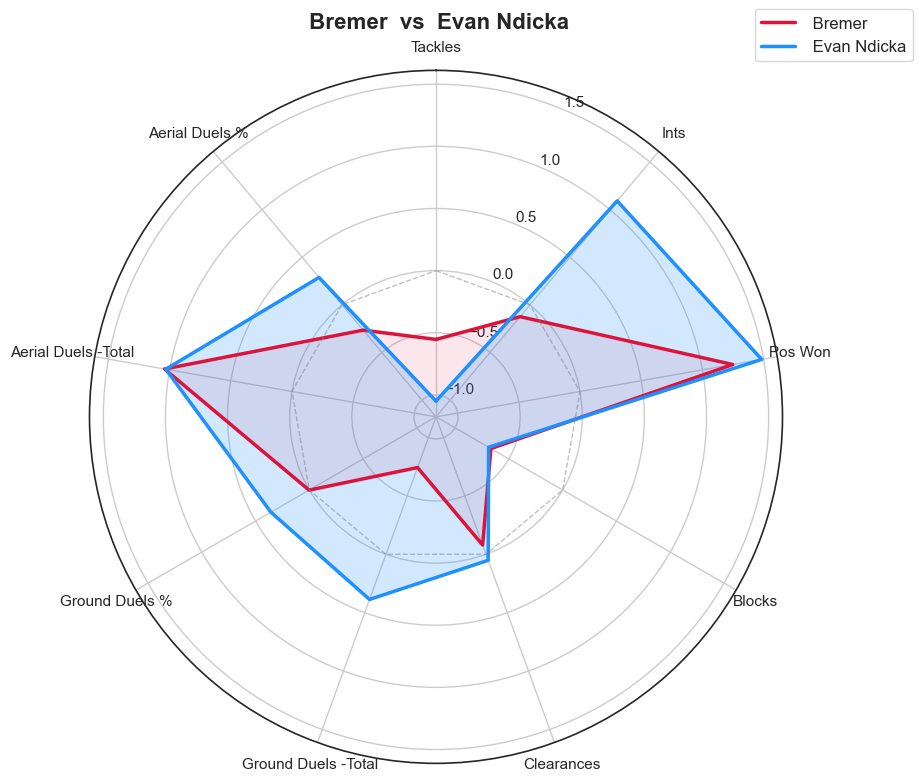


——————————————————————————————————————————————————————————————————————
 SCOUTING: PROACTIVE AGGRESSOR
 TARGET:  Giorgio Scalvini
——————————————————————————————————————————————————————————————————————


,name,team,Cluster,Cluster_0_%,Cluster_1_%,Cluster_2_%,Cluster_3_%,Distance
10,Juan Jesus,Napoli,0,39.600000,17.200000,24.500000,18.800000,1.216255
0,Isak Hien,Atalanta,0,45.000000,15.400000,23.400000,16.300000,1.966611
35,Gianluca Mancini,Roma,0,72.700000,8.500000,10.200000,8.700000,3.045672
1,Jhon Lucumí,Bologna,0,43.500000,14.100000,24.800000,17.600000,3.241894
19,Jacobo Ramón,Como,0,42.700000,20.700000,20.400000,16.300000,3.460781
15,Alessandro Buongiorno,Napoli,0,39.200000,21.400000,20.800000,18.600000,3.472012
18,Manuel Akanji,Inter,0,49.900000,13.300000,20.700000,16.200000,3.567740


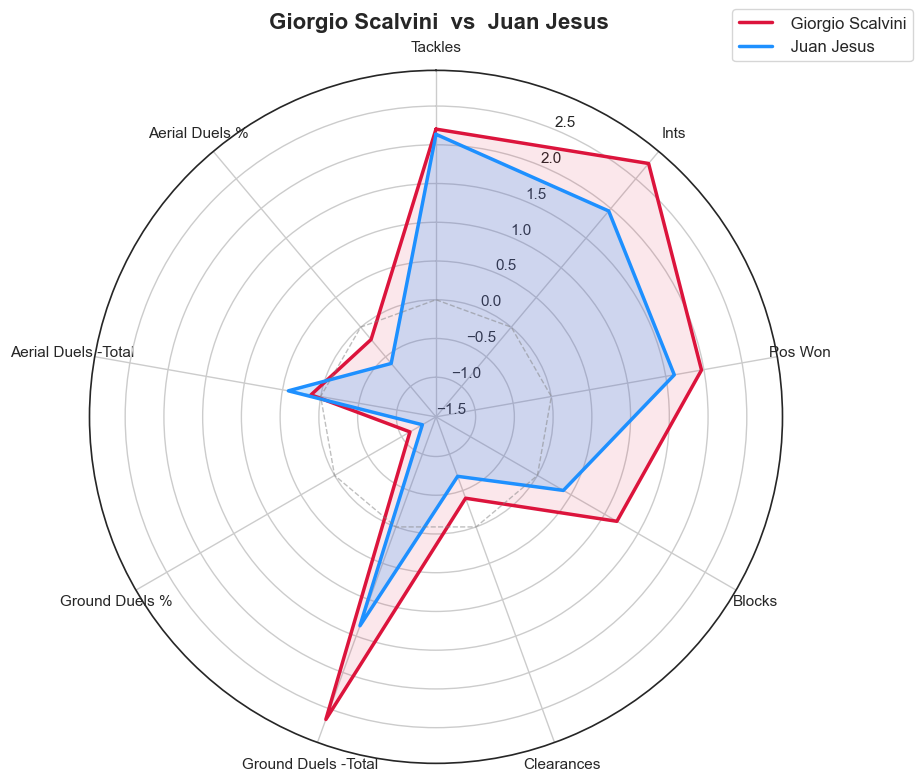

In [41]:
from scipy.spatial.distance import euclidean

def find_tactical_clones(target_player, df_pca_data, df_full, top_n=7):
    # Check if the player exists in the dataset
    if target_player not in df_full['name'].values:
        return f"Player '{target_player}' not found."
    
    # PCA coordinates for the target 
    target_idx = df_full[df_full['name'] == target_player].index[0]
    target_coords = df_pca_data.loc[target_idx, ['PC1', 'PC2', 'PC3', 'PC4']].values
    
    distances = []
    
    # Calculate distance between target and every other defender
    for idx, row in df_pca_data.iterrows():
        if idx == target_idx:
            continue 
            
        compare_coords = row[['PC1', 'PC2', 'PC3', 'PC4']].values
        dist = euclidean(target_coords, compare_coords)
        distances.append((idx, dist))
        
    # Sort by distance
    distances.sort(key=lambda x: x[1])
    
    top_indices = [x[0] for x in distances[:top_n]]
    cols_to_show = ['name', 'team', 'Cluster', 'Cluster_0_%', 'Cluster_1_%', 'Cluster_2_%', 'Cluster_3_%']
    clones = df_full.loc[top_indices, cols_to_show].copy()
    clones['Distance'] = [x[1] for x in distances[:top_n]]
    
    return clones


def plot_scouting_radar(player1, player2, df_full, radar_features):
    labels = [f.replace('_padj_z', '').replace('_z', '').title() for f in radar_features]
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1] 

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

    val_1 = df_full[df_full['name'] == player1][radar_features].values[0].tolist()
    val_1 += val_1[:1]
    ax.plot(angles, val_1, color='crimson', linewidth=2.5, label=player1)
    ax.fill(angles, val_1, color='crimson', alpha=0.1)

    val_2 = df_full[df_full['name'] == player2][radar_features].values[0].tolist()
    val_2 += val_2[:1]
    ax.plot(angles, val_2, color='dodgerblue', linewidth=2.5, label=player2)
    ax.fill(angles, val_2, color='dodgerblue', alpha=0.2)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11)
    
   
    ax.plot(angles, [0]*len(angles), color='grey', linestyle='--', linewidth=1, alpha=0.5)

    ax.set_title(f'{player1}  vs {player2}', size=16, fontweight='bold', pad=30)
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=12)

    plt.show()


# Testing 3 different profiles to see the shortlist variety
targets = [
    {'name': ' Alessandro Bastoni', 'desc': 'Ball-playing specialist'},
    {'name': ' Bremer', 'desc': 'Traditional box protector'},
    {'name': ' Giorgio Scalvini', 'desc': 'Proactive aggressor'}
]

for t in targets:
    print(f"\n" + "—"*70)
    print(f" SCOUTING: {t['desc'].upper()}")
    print(f" TARGET: {t['name']}")
    print("—"*70)
    
    shortlist = find_tactical_clones(t['name'], df_pca, df, top_n=7)
    
    if isinstance(shortlist, pd.DataFrame):
        display(shortlist.style.background_gradient(cmap='RdYlGn_r', subset=['Distance']))
        
        best_match = shortlist.iloc[0]['name']
        plot_scouting_radar(t['name'], best_match, df, z_columns)

### Key Insights from the Scouting Showcase

The results from the similarity engine show that the model is capturing actual tactical roles, not just random correlations. Here are the main takeaways:

* **The Bastoni-Augusto Connection:** Finding **Carlos Augusto** as the #1 match for Bastoni is the ultimate validation. In Inter's tactical system, Augusto is the natural replacement for Bastoni's role. The fact that the engine picked him purely based on PCA coordinates—and verified it through nearly identical Tactical DNA (both sharing a ~41% membership in Cluster 0 with an incredibly low Euclidean distance of 1.30)—proves it has correctly identified the "Ball-playing" profile. Other names like **Oumar Solet** and **Jhon Lucumí** emerge as high-value "hidden gems" for clubs looking for that same progressive DNA.

* **Bremer's Hybrid Profile:** The shortlist for Bremer reveals why he is an elite defender. His closest match is **Evan Ndicka** (distance 1.20), but the list immediately follows with pure Box Protectors (Cluster 1) like **Federico Gatti**. This reflects Bremer's hybrid nature: he has the physicality of an old-school center-back but the mobility required in a modern high line, quantified by his evenly distributed Cluster Memberships. Interestingly, **Yann Bisseck** appears in multiple shortlists, suggesting he is one of the most tactically flexible defenders in the league.

* **Scalvini's Defensive Style:** The search for Scalvini confirms his highly specific role. While **Juan Jesus** (1.21) and **Isak Hien** (1.96) show a good level of similarity, the distances increase much faster than in Bastoni's case. By the third result (**Gianluca Mancini**), we are already at a distance of 3.04. Furthermore, Mancini is a pure "Specialist" (72.7% in Cluster 0), lacking Scalvini's hybrid nuances. This indicates that while "aggressive" defenders exist, finding a perfect tactical clone for Scalvini is harder, as the pool of players with his specific high-risk, high-reward profile is narrower.

## Team Tactical DNA: Profiling Defensive Systems

To understand how individual player profiles translate into collective tactical systems, we aggregated our results at the team level. Instead of just counting players, we weighted their presence by **minutes played** to get a more accurate picture of each team's actual identity on the pitch.

This step serves as a **system validation**. The 100% stacked bar chart confirms that the model reflects reality: teams known for high-pressing and proactive defending (like Roma, Inter, and Napoli) are dominated by **Cluster 0 (Proactive)** players. On the other hand, teams that rely on a deep defensive block (like Lecce) show a much higher reliance on **Cluster 1 (Box Protectors)**. 

Seeing our clusters align so clearly with the known philosophies of Serie A managers ensures that our scouting profiles are grounded in tactical reality.

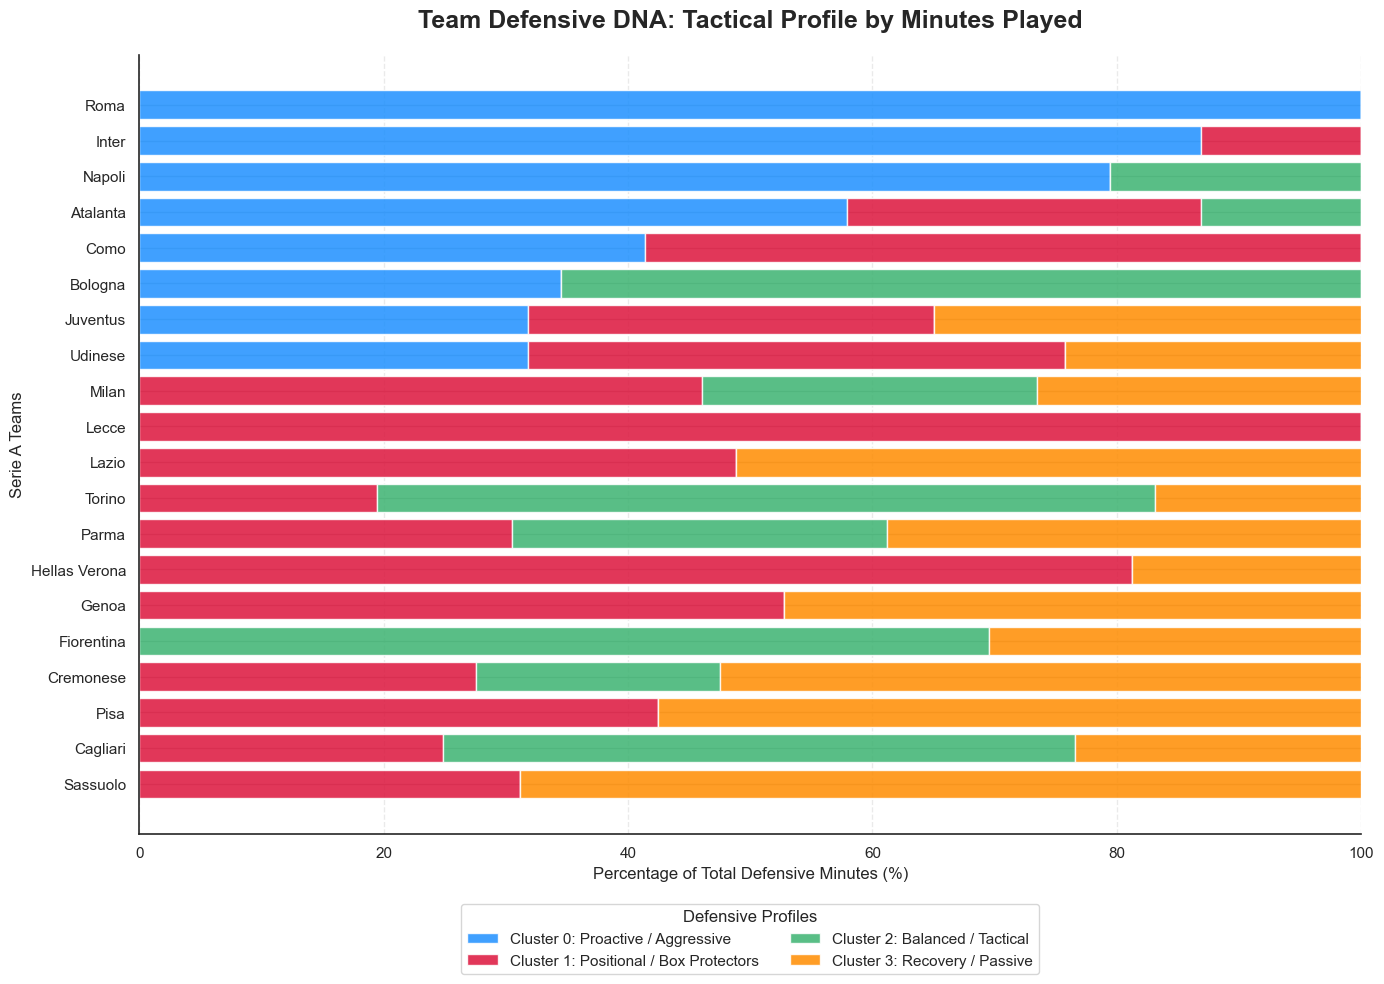

In [34]:
# Group by Team and Cluster, summing the minutes played
team_cluster_mins = df.groupby(['team', 'Cluster'])['mins'].sum().unstack(fill_value=0)

# Normalize the data to get percentages (0-100%) for each team
team_dna_pct = team_cluster_mins.div(team_cluster_mins.sum(axis=1), axis=0) * 100

# Sort teams by the percentage of Cluster 0 (Aggressive)
team_dna_pct = team_dna_pct.sort_values(by=0, ascending=True)

colors = ['dodgerblue', 'crimson', 'mediumseagreen', 'darkorange']
cluster_labels = [
    'Cluster 0: Proactive / Aggressive', 
    'Cluster 1: Positional / Box Protectors', 
    'Cluster 2: Balanced / Tactical', 
    'Cluster 3: Recovery / Passive'
]

fig, ax = plt.subplots(figsize=(14, 10))

bottom = np.zeros(len(team_dna_pct))

for i, col in enumerate(team_dna_pct.columns):
    values = team_dna_pct[col].values
    ax.barh(team_dna_pct.index, values, left=bottom, color=colors[i], 
            edgecolor='white', label=cluster_labels[i], alpha=0.85)
    bottom += values

ax.set_title('Team Defensive DNA: Tactical Profile by Minutes Played', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Percentage of Total Defensive Minutes (%)', fontsize=12)
ax.set_ylabel('Serie A Teams', fontsize=12)
ax.set_xlim(0, 100)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2, fontsize=11, title="Defensive Profiles")

plt.tight_layout()
plt.show()

### Project Conclusion

This analysis successfully translated raw defensive metrics into a structured tactical framework. By leveraging PCA and K-Means clustering, we identified four distinct defensive profiles that accurately reflect the tactical reality of Serie A. 

Beyond group classification, the use of **Local Outlier Factor (LOF)** allowed us to isolate unique tactical players, while the **Similarity Engine** provided a data-driven method for identifying statistical clones of elite defenders. The final team-level validation confirms that these individual profiles aggregate into recognizable collective systems.



In [42]:
# Export processed data for the Streamlit dashboard
df.to_csv('processed_defenders_data.csv', index=False)
df_pca.to_csv('pca_coordinates.csv', index=False)

import json
with open('radar_metrics.json', 'w') as f:
    json.dump(z_columns, f)